In [50]:
import gpt as g
import numpy as np
import qlat as q
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.linalg import inv
from scipy.linalg import eigh
from scipy.stats import f as fdist
from abc import ABC, abstractmethod
from jackknife import *

# Two pion scattering in the $I=0$ channel

## Helper functions

In [54]:
class Ensemble_jks():
    #C2pt_jks is of shape (nOp, nOp, ncf, tsep_max)
    #Cvev_jks is of shape (nOp, ncf, nt)
    def __init__(self,C2pt_jks):
        self.nOp = C2pt_jks.shape[0] #input jks data is of shape (nOp, nOp, ncf, nt)
        self.ncf = C2pt_jks.shape[2]
        self.nt = C2pt_jks.shape[3]
        self.C2pt_jks = C2pt_jks 
        self.jks = C2pt_jks
        
        self.vec = 0
        self.e = 0
        pass

## $I = 0$ $5 \times 5$ GEVP

### single config verification

In [29]:
ld_pp.info()[0]

['expr_name',
 82,
 ['< 1 >  exprs[0]',
  '< sigma^dag(0) * sigma(-tsep) >  exprs[1]',
  '< wf_src(0) * sigma^dag(0) * pipi_i00(-tsep) > (ADT1_pps)  exprs[2]',
  '< wf_src(0) * sigma^dag(0) * pipi_i00(-tsep) > (ADT2_pps)  exprs[3]',
  '< wf_src(0) * sigma^dag(0) * pipi_i00(-tsep) > (ADT1_spp)  exprs[4]',
  '< wf_src(0) * sigma^dag(0) * pipi_i00(-tsep) > (ADT2_spp)  exprs[5]',
  '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[6]',
  '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT2)  exprs[7]',
  '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT3)  exprs[8]',
  '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT4)  exprs[9]',
  '< wf_snk(1) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[10]',
  '< wf_snk(1) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT2)  exprs[11]',
  '< wf_snk(1) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT3)  exprs[12]',
  '< wf_snk(1) * wf_src(0) * p

In [302]:
#dst_3 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-type/traj-1102/pipi_corr_psnk_psrc.lat"
dst_vev1 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D1/traj-1505/pipi_vev.lat"
dst_vev2 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-p/traj-1505/pipi_vev.lat"

#dst_meson = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-p-sigma/traj-1142/meson_corr_psnk_psrc_psel.lat"

dst_pp = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D1/traj-1505/pipi_corr_psnk_psrc.lat"
dst_pp2 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-p/traj-1505/pipi_corr_psnk_psrc.lat"
#dst_avg = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-pos-avg/traj-1112/pipi_vev_pos_avg.lat"


#ld_meson = q.load_lat_data(dst_meson)
ld_vev1 = q.load_lat_data(dst_vev1)
ld_vev2 = q.load_lat_data(dst_vev2)
ld_pp = q.load_lat_data(dst_pp)
ld_pp2 = q.load_lat_data(dst_pp2)
#ld_avg = q.load_lat_data(dst_avg)

ld_vev2.info()[0][2]

['< 1 >  exprs[0]',
 '< sigma(-tsep) >  exprs[1]',
 '< sigma^dag(0) >  exprs[2]',
 '< wf_src(0) * pipi_i0(-tsep) >  exprs[3]',
 '< wf_snk(0) * pipi_i0^dag(0) >  exprs[4]',
 '< wf_src(1) * pipi_i0(-tsep) >  exprs[5]',
 '< wf_snk(1) * pipi_i0^dag(0) >  exprs[6]',
 '< wf_src(2) * pipi_i0(-tsep) >  exprs[7]',
 '< wf_snk(2) * pipi_i0^dag(0) >  exprs[8]',
 '< wf_src(3) * pipi_i0(-tsep) >  exprs[9]',
 '< wf_snk(3) * pipi_i0^dag(0) >  exprs[10]']

In [228]:
total_volume = 48*48*48*96
#arr_meson = ld_meson.to_numpy()
arr_vev1 = ld_vev1.to_numpy()
arr_vev2 = ld_vev2.to_numpy()
#arr_all = ld_all.to_numpy()
arr_pp = ld_pp.to_numpy()
arr_pp2 = ld_pp2.to_numpy()
#arr_avg = ld_avg.to_numpy()
t = np.linspace(1,95,95)
t_sep = np.linspace(1,20,19)

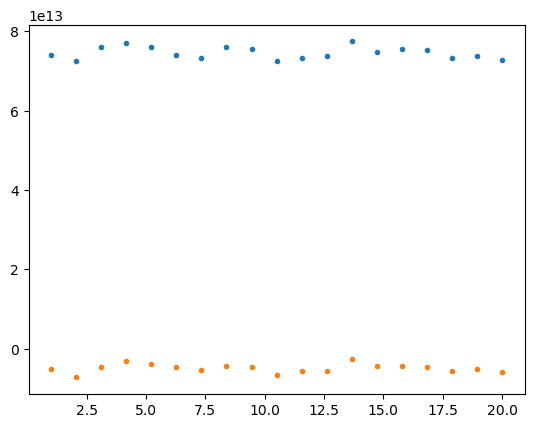

In [244]:
fig, ax = plt.subplots()
ax.plot(t_sep,arr_pp[56,1:20].real,marker='.',ls='')
ax.plot(t_sep,arr_pp[58,1:20],marker='.',ls='')
#ax.set_ylim(0,9e10)

In [264]:
arr_avg[1,:,1,1]

array([    0.          +0.j        ,     0.          +0.j        ,
           0.          +0.j        ,     0.          +0.j        ,
           0.          +0.j        ,     0.          +0.j        ,
           0.          +0.j        ,     0.          +0.j        ,
       -2839.71125288 +14.50998741j,  -987.3789918   -2.01717556j,
           0.          +0.j        ,     0.          +0.j        ,
           0.          +0.j        ,     0.          +0.j        ,
           0.          +0.j        , -1185.33884634  +4.054355j  ,
           0.          +0.j        , -2478.15595884 -15.67441096j,
       -3177.47536638-379.60878906j,     0.          +0.j        ,
           0.          +0.j        ,     0.          +0.j        ,
           0.          +0.j        , -1870.35116123 +14.52341917j,
           0.          +0.j        ])

In [250]:
counter = arr_avg[0,:,:,:]

In [251]:
mask = counter != 0
avg = np.zeros_like(counter)
avg[mask] = arr_avg[1,mask]/counter[mask]

In [269]:
z_avg = np.sum(np.sum(avg[:,:,:],axis=1),axis=0)

In [578]:
pipi_count = arr_pp[0,:,0] #two factors of volume normalization
vev_count = arr_vev[0,:] # one factor of volume normalization

In [85]:
np.sum(arr_avg[1,:]/total_volume)

np.complex128(-1251.282532656148+0.8696226200679085j)

(-0.0005, 0.0)

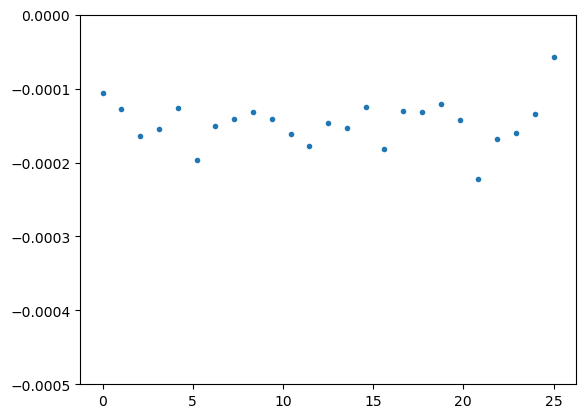

In [270]:
tsep = np.linspace(0,25,25)
fig, ax = plt.subplots()
ax.plot(tsep, z_avg, marker='.', ls='')
#ax.plot(tsep, S, marker='.', ls='')
ax.set_ylim(-0.0005, 0)


In [139]:
t_size = 96
t_sep_size = 96
S = np.zeros(96, dtype=np.complex128)
for tsep in range(0,96):
    s = 0.0
    for tsrc in range(t_size):
        t_1 = (tsep + tsrc) % t_size
        s += (arr_vev[3,t_1])*(arr_vev[4,tsrc])

    S[tsep] = s

In [140]:
(S[:24])/(total_volume**2)

array([0.00071529+6.59722608e-07j, 0.00057976+4.48269613e-08j,
       0.00060015+2.21080090e-07j, 0.00059598+3.35831988e-07j,
       0.0005688 +6.54340387e-08j, 0.00063452-2.18056779e-08j,
       0.00057954+2.30828983e-08j, 0.00059975+1.35830649e-07j,
       0.00058998+2.92717122e-08j, 0.00058751+2.62695684e-07j,
       0.00058076-2.54848908e-07j, 0.00056194+3.34973088e-07j,
       0.00057565+4.70049168e-08j, 0.00057461+1.24914421e-07j,
       0.00060478+4.56365565e-07j, 0.00058527+1.68274542e-07j,
       0.00057024+1.60214179e-07j, 0.00056529+5.42104468e-07j,
       0.00057488+9.34262228e-08j, 0.0005815 +4.45562563e-07j,
       0.00057162+1.09470899e-07j, 0.00058198+2.11109924e-07j,
       0.00055356-2.25832837e-07j, 0.00057972-2.93079823e-08j])

In [114]:
np.sum(arr_vev[1,:])*np.sum(arr_vev[1,:])

np.complex128(0.0572325727993707-5.0277376751738736e-06j)

In [324]:
np.sum(arr_vev[2,:]/0.00019)

np.complex128(-0.233614206810421+7.611048742241748e-06j)

/nix/store/sypv6c2g3j9yqsks9kd8ksbqbfz1jf5v-python3-3.13.9-env/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


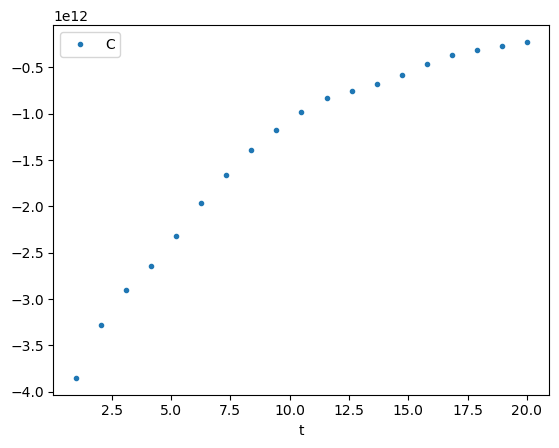

In [305]:
t = np.linspace(1,96,95)
#t_sep = np.linspace(1,16,15)
t_sep = np.linspace(1,20,19)
fig, ax = plt.subplots()
#ax.plot(t_sep, pipi_sub[0,1:], marker='.', ls='',label="(0,0,0)")
#ax.plot(t_sep, pipi_sub[1,1:], marker='.', ls='',label="(0,0,1)")
#ax.plot(t_sep, pipi_sub[2,1:], marker='.', ls='',label="(0,1,1)")
#ax.plot(t_sep, pipi_sub[3,1:], marker='.', ls='',label="(1,1,1)")

#ax.plot(t_sep, arr_pp[16,1:],marker='.',ls='',label="D")
ax.plot(t_sep, arr_pp[2,1:],marker='.',ls='',label="C")
#ax.plot(t_sep, arr_pp[3,1:],marker='.',ls='', label="R")
#ax.plot(t_sep, arr_pp[4,1:],marker='.',ls='', label="V")

#ax.plot(t_sep, arr_ps[1,1:,0],marker='.',ls='')

#ax.plot(t, np.sum(arr_vev_meson1[1,1:,:],axis=1),marker='.', ls='',label=r"$\langle \sigma (t) \rangle$")
#ax.plot(t, np.sum(arr_vev_meson1[2,1:,:],axis=1),marker='.', ls='',label=r"$\langle \sigma^{\dagger}(0) \rangle$")

#ax.set_yscale("log")
#ax.set_ylim(10, 20)
#ax.set_title(r"$\langle O_{\pi\pi,i}(t) \ O_{\pi\pi,i}^{\dagger}(0) \rangle - \frac{1}{L_t}\sum_{t_s=0}^{L_t-1}\langle O_{\pi\pi,i}(t+t_s\rangle\langle O_{\pi\pi,i}^{\dagger}(t_s) \rangle$")
ax.set_xlabel("t")
ax.legend();

### sigma analysis and subtraction

#### Single config verification

In [3]:
ld = q.load_lat_data(f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-V/traj-{1122}/vac_corr_psnk_psrc.lat")

In [26]:
dst = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-V/traj-1142/vac_corr_psnk_psrc.lat"

ld_1232 = q.load_lat_data(dst)

ld_1232.info()[0][2]

['< 1 >  exprs[0]',
 '< wf_snk(0) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0>) * (pipi_i00(-tsep) - <pipi_i0>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[1]',
 '< wf_snk(0) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0_t>) * (pipi_i00(-tsep) - <pipi_i0_t>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[2]',
 '< wf_snk(0) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0_jk>) * (pipi_i00(-tsep) - <pipi_i0_jk>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[3]',
 '< wf_snk(0) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0_jk>) * (pipi_i00(-tsep) - <pipi_i0_jk>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[4]',
 '< wf_snk(1) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0>) * (pipi_i00(-tsep) - <pipi_i0>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[5]',
 '< wf_snk(1) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0_t>) * (pipi_i00(-tsep) - <pipi_i0_t>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[6]',
 '< wf_snk(1) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0_jk>) * (pipi_i00(-tsep) - <pipi_i0_jk>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[7]',
 '< wf_snk(1) * 

In [27]:
arr_1232 = ld_1232.to_numpy()
print(arr_1232.shape)

(65, 22)


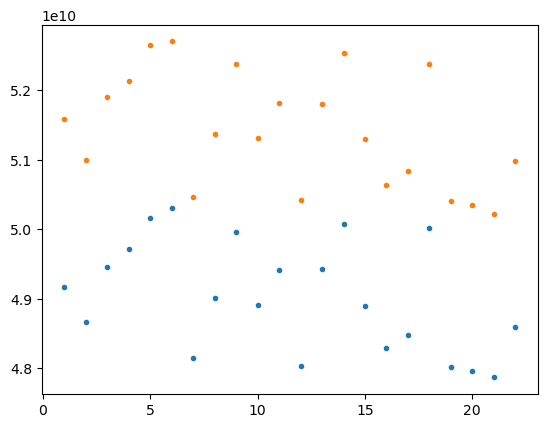

In [29]:
ts = np.linspace(1,22,22)
fig, ax = plt.subplots()
ax.plot(ts, arr_1222[2],marker='.',ls='',label='')
ax.plot(ts, arr_1222[4],marker='.',ls='',label='')
#ax.plot(ts, arr_1222[3,1:],marker='.',ls='')
#ax.plot(ts, arr_1222[4,1:],marker='.',ls='')
#ax.set_ylim(0,1e10)

#### Load data

In [70]:
#here we load in the sigma correlator data and all vev data

dst_list_1 = []
meson_data = []
vev_data = []

for traj in range(1112,1293,10):
    #print(traj)
    dst = f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-sigma/traj-{traj}/meson_corr_psnk_psrc_psel.lat"
    dstvev = f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-vev/traj-{traj}/pipi_vev.lat"
    meson_data.append(q.load_lat_data(dst).to_numpy())
    vev_data.append(q.load_lat_data(dstvev).to_numpy())

for traj in range(1312,1483,10):
    dst = f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-sigma/traj-{traj}/meson_corr_psnk_psrc_psel.lat"
    dstvev = f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-vev/traj-{traj}/pipi_vev.lat"
    meson_data.append(q.load_lat_data(dst).to_numpy())
    vev_data.append(q.load_lat_data(dstvev).to_numpy())

ncf_meson = len(meson_data)
meson_arr = np.array(meson_data)
vev_arr = np.array(vev_data)

In [77]:
meson_arr_jk = jackblocks_expr(meson_arr, omit=[])
meson_arr_jk.shape

(37, 4, 96)

In [78]:
#picking out just the sigma vev data
ncf = meson_arr.shape[0]
nt = meson_arr.shape[-1]
sigma_vev_arr = np.zeros((ncf, 2, nt))
sigma_vev_arr = vev_arr[:,1:3,:]

sigma_vev_jk = jackblocks_expr(sigma_vev_arr,omit=[])
sigma_vev_jk.shape

(37, 2, 96)

In [79]:
#constructing the total correlator as a sum of the two types
ncf = meson_arr.shape[0]
nt = meson_arr.shape[-1]
meson_total = np.zeros((ncf, nt),dtype=np.complex128)
for cf in range(ncf):
    meson_total[cf,:] = (meson_arr[cf,1,:] + meson_arr[cf,2,:])

meson_total_jk = jackblocks(meson_total, omit=[])

In [80]:
meson_avg, meson_err = jack(meson_arr_jk.real)
meson_total_avg, meson_total_err = jack(meson_total_jk.real)

In [84]:
meson_sub = vac_sub(meson_total_jk, sigma_vev_arr[:,0,:], sigma_vev_arr[:,1,:], Delta=0)

(0.051627580032970966+0.00012713917202368492j)
Subtraction term standard deviation: 0.0009202004452175276


In [22]:
meson_sub_avg, meson_sub_err = jack(meson_sub.real)

(0.0, 0.005)

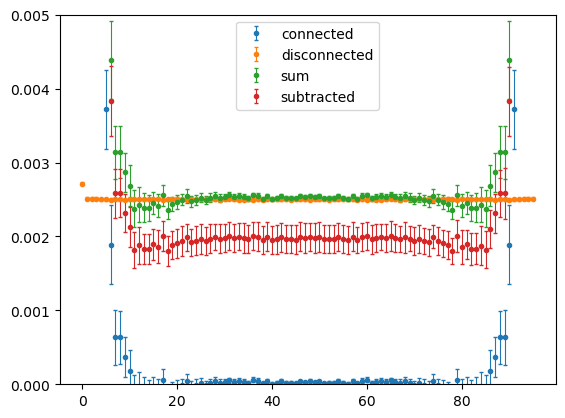

In [23]:
t = np.linspace(0,95,96)
fig, ax = plt.subplots()
ax.errorbar(t, meson_avg[1,:], yerr=meson_err[1,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label="connected")
ax.errorbar(t, meson_avg[2,:], yerr=meson_err[2,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label="disconnected")
#ax.errorbar(t, meson_avg[3,:], yerr=meson_err[3,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label="total")
ax.errorbar(t, meson_total_avg, yerr=meson_total_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="sum")
ax.errorbar(t, meson_sub_avg, yerr=meson_sub_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="subtracted")
ax.legend();
ax.set_ylim(0,0.005)

In [93]:
dst_meson = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-sigma/"
dst_list_1 = []
meson_data = []

for traj in range(1102,1493,10):
    dst = f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-sigma/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    meson_data.append(q.load_lat_data(dst).to_numpy())

for traj in range(1505,1636,10):
    dst = f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-sigma/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    meson_data.append(q.load_lat_data(dst).to_numpy())

for traj in range(1705,2176,10):
    if traj == 2035 or traj == 2075:
        pass
    else:
        dst = f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-sigma/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
        meson_data.append(q.load_lat_data(dst).to_numpy())

for traj in range(975,1096,10):
    dst = f"/home/jhildebrand28/ktopipi/results/48I/auto-contract-sigma/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    meson_data.append(q.load_lat_data(dst).to_numpy())

ncf_meson = len(meson_data)
meson_arr = np.array(meson_data)

In [94]:
meson_arr.shape

(113, 5, 96)

In [95]:
sigma_jks = jackblocks_all(meson_arr,omit=[])

tol=1e-12
counter_jks = sigma_jks[:,0,:]
sigma_norm_T1 = np.divide(sigma_jks[:,1,:],counter_jks,where=(counter_jks>tol))
sigma_norm_T2 = np.divide(sigma_jks[:,2,:],counter_jks,where=(counter_jks>tol))
sigma_norm_total = np.divide(sigma_jks[:,3,:],counter_jks,where=(counter_jks>tol))
sigma_norm_sub = np.divide(sigma_jks[:,4,:], counter_jks, where=(counter_jks>tol))

sigma_n_T1_avg, sigma_n_T1_err = jack_all(sigma_norm_T1.real)
sigma_n_T2_avg, sigma_n_T2_err = jack_all(sigma_norm_T2.real)
sigma_n_total_avg, sigma_n_total_err = jack_all(sigma_norm_total.real)
sigma_avg, sigma_err = jack_all(sigma_jks.real)

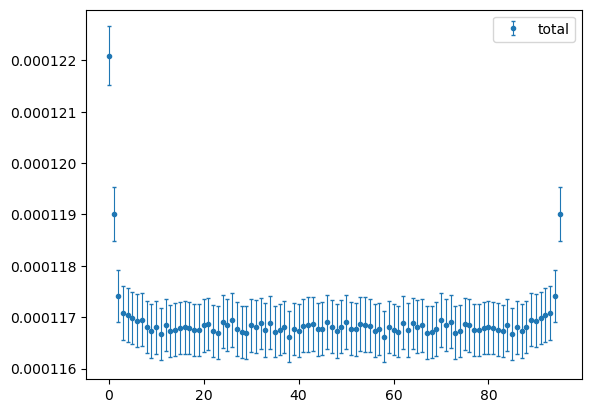

In [96]:
t = np.linspace(0,95,96)
fig, ax = plt.subplots()
#ax.errorbar(t, meson_avg[1,:], yerr=meson_err[1,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label="connected")
#ax.errorbar(t, meson_avg[2,:], yerr=meson_err[2,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label="disconnected")
#ax.errorbar(t, meson_avg[3,:], yerr=meson_err[3,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label="total")

#ax.errorbar(t, sigma_n_T1_avg, yerr=sigma_n_T1_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="connected")
#ax.errorbar(t, sigma_n_T2_avg, yerr=sigma_n_T2_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="disconnected")
ax.errorbar(t, sigma_n_total_avg, yerr=sigma_n_total_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="total")
ax.legend()

#### Subtraction method 1

In [97]:
#get vev data for the same configurations
sigma_vev_counts = vev_arr_p[:,0,:]
sigma_vev_arr = vev_arr_p[:,1,:]

sig_vev_count_jks = jackblocks_all(sigma_vev_counts,omit=[])
sigma_vev_jks = jackblocks_all(sigma_vev_arr,omit=[])

sigma_norm_vev = np.divide(sigma_vev_jks,sig_vev_count_jks,where=(sig_vev_count_jks>1e-12))

In [98]:
sigma_sub_term = sub_term(sigma_norm_vev,sigma_norm_vev,Delta=0)
#sigma_total = sigma_jks[:,3,:]
#sigma_sub_term_norm = sub_term(sigma_norm_vev,sigma_norm_vev,Delta=0)

sigma_vac_sub = sigma_norm_total - sigma_sub_term

sigma_vacsub_avg, sigma_vacsub_err = jack_all(sigma_vac_sub.real)

(113, 96)
(113, 96)
Subtraction term standard deviation: 4.972034928648354e-08


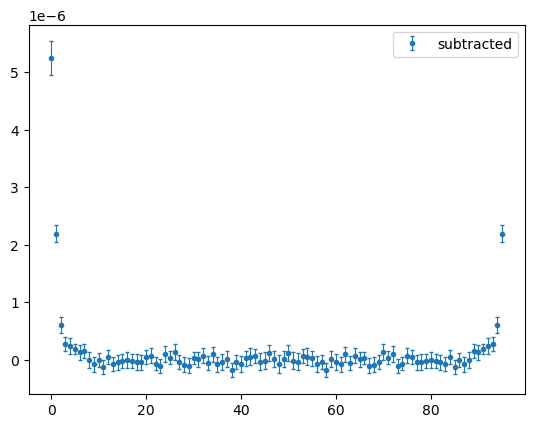

In [99]:
t = np.linspace(0,95,96)
fig, ax = plt.subplots()
#ax.errorbar(t, sigma_n_T1_avg, yerr=sigma_n_T1_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="connected")
#ax.errorbar(t, sigma_n_T2_avg, yerr=sigma_n_T2_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="disconnected")
#ax.errorbar(t, sigma_n_total_avg, yerr=sigma_n_total_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="total")
ax.errorbar(t, sigma_vacsub_avg, yerr=sigma_vacsub_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="subtracted")
ax.legend()

#### Subtraction method 2

In [100]:
#We have the subtracted vev data straight from the auto contractor
sigma_conn = meson_arr[:,1,:]
sigma_sub_V = meson_arr[:,4,:]
ncf = sigma_conn.shape[0]
nt = sigma_conn.shape[1] 
sigma_sub_total = np.zeros_like(sigma_conn)

#type addition happens configuration by configuration
for cf in range(ncf):
    sigma_sub_total[cf,:] = sigma_conn[cf,:] + sigma_sub_V[cf,:]
    
sig_sub_jks = jackblocks_all(sigma_sub_total,omit=[])

sig_sub_norm = np.divide(sig_sub_jks,counter_jks,where=(counter_jks>1e-12))

sig_sub_avg,sig_sub_err = jack_all(sig_sub_jks.real)
sig_sub_norm_avg, sig_sub_norm_err = jack_all(sig_sub_norm.real)

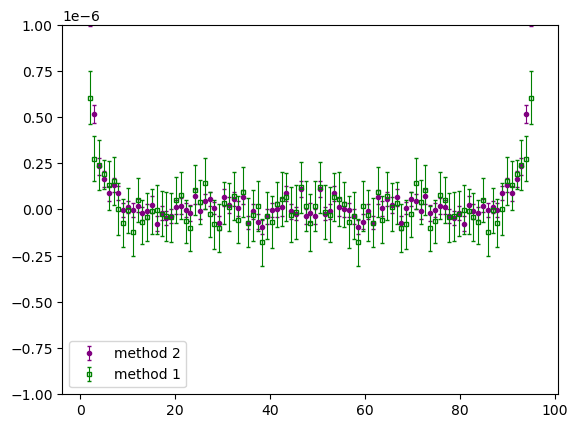

In [103]:
t = np.linspace(1,96,95)
fig, ax = plt.subplots()
ax.errorbar(t, sig_sub_norm_avg[1:], yerr=sig_sub_norm_err[1:], marker='o', markersize=3, markeredgecolor= 'purple',ls='', elinewidth=0.8, capsize=1.5, color='purple', label="method 2")
ax.errorbar(t, sigma_vacsub_avg[1:], yerr=sigma_vacsub_err[1:], marker='s', markersize=3, markerfacecolor= 'none', markeredgecolor= 'green', ls='', elinewidth=0.8, capsize=1.5, color='green', label="method 1")
#ax.errorbar(t, sig_ts_avg[1:], yerr=sig_ts_err[1:], marker='d', markersize=3, markerfacecolor='none', markeredgecolor= 'blue',ls='', elinewidth=0.8, capsize=1.5, color='blue', label="ts")
ax.set_ylim(-1e-6,1e-6)
ax.legend();

In [462]:
sig_sub_norm_err[1:40]

array([1.53586386e-07, 5.03635980e-08, 4.84157119e-08, 4.74953565e-08,
       4.18380642e-08, 4.12764068e-08, 3.66286475e-08, 3.71100814e-08,
       3.87224954e-08, 3.33763421e-08, 3.61416844e-08, 3.53327645e-08,
       3.45705316e-08, 4.05926892e-08, 4.65331348e-08, 4.11611322e-08,
       3.76481429e-08, 3.66086764e-08, 3.83757958e-08, 3.81930898e-08,
       4.36107770e-08, 3.59240599e-08, 4.42894103e-08, 4.06237385e-08,
       3.80293243e-08, 4.28854141e-08, 3.84377481e-08, 3.35954600e-08,
       3.73157131e-08, 4.43899403e-08, 4.15025222e-08, 3.76843551e-08,
       4.04358738e-08, 3.72615108e-08, 3.59211210e-08, 3.81265912e-08,
       4.08424228e-08, 3.74942274e-08, 3.93129161e-08])

#### Subtraction technique comparison

In [14]:
ld_test = q.load_lat_data(dst_meson + "traj-995/meson_corr_psnk_psrc_mom.lat")
ld_test.info()[0][2]

['< 1 >  exprs[0]',
 '< wf(0) * sigma^dag(0) * sigma_0(-tsep) > (Type1)  exprs[1]',
 '< (sigma(-tsep) - <sigma>) * (sigma(0)^dag - <sigma_const>) >  exprs[2]',
 '< (sigma(-tsep) - <sigma>) * (sigma(0)^dag - <sigma_jk>) >  exprs[3]',
 '< (sigma(-tsep) - <sigma>) * (sigma(0)^dag - <sigma_avg>) >  exprs[4]']

In [104]:
dst_meson = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-sigma-2/"
meson_data_2 = []

for traj in range(1102,1493,10):
    dst = dst_meson + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    meson_data_2.append(q.load_lat_data(dst).to_numpy())

for traj in range(1505,1636,10):
    dst = dst_meson + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    meson_data_2.append(q.load_lat_data(dst).to_numpy())

for traj in range(1705,2176,10):
    if traj == 2035 or traj == 2075:
        pass
    else:
        dst = dst_meson + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
        meson_data_2.append(q.load_lat_data(dst).to_numpy())

for traj in range(975,1096,10):
    dst = dst_meson + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    meson_data_2.append(q.load_lat_data(dst).to_numpy())

ncf_meson = len(meson_data_2)
meson_arr_2 = np.array(meson_data_2)
print(meson_arr_2.shape)

(113, 5, 96)


In [105]:
#function that adds the two types of the sigma correlator given arrays of shape (ncf,nt) for both inputs. 
def sigma_type_add(sigma_t1, sigma_vac):
    ncf = sigma_t1.shape[0]
    nt = sigma_t1.shape[1]

    sigma_total = np.zeros_like(sigma_t1)
    
    for cf in range(ncf):
        sigma_total[cf,:] = sigma_t1[cf,:] + sigma_vac[cf,:]

    return sigma_total

In [106]:
#expression order is constant, jackknife, timeslice.
counters = meson_arr_2[:,0,:]
sigma_t1 = meson_arr_2[:,1,:]
sigma_const = meson_arr_2[:,2,:]
sigma_jk = meson_arr_2[:,3,:]
sigma_ts = meson_arr_2[:,4,:]

#addition happens config by config, so we construct the three sigma correlators here
#sig_const = sigma_type_add(sigma_t1, sigma_const)
#sig_jk = sigma_type_add(sigma_t1, sigma_jk)
#sig_ts = sigma_type_add(sigma_t1, sigma_ts)

#then we jackknife and normalize by the counters
counters_jk = jackblocks_all(counters,omit=[])
sig_const_jk = jackblocks_all(sigma_const,omit=[])
sig_jk_jk = jackblocks_all(sigma_jk,omit=[])
sig_ts_jk = jackblocks_all(sigma_ts,omit=[])

sig_c_norm = np.divide(sig_const_jk,counters_jk,where=(counters_jk>1e-12))
sig_jk_norm = np.divide(sig_jk_jk,counters_jk,where=(counters_jk>1e-12))
sig_ts_norm = np.divide(sig_ts_jk,counters_jk,where=(counters_jk>1e-12))


sig_c_avg, sig_c_err = jack_all(sig_c_norm)
sig_jk_avg, sig_jk_err = jack_all(sig_jk_norm)
sig_ts_avg, sig_ts_err = jack_all(sig_ts_norm)

print(sig_c_avg.shape)

(96,)


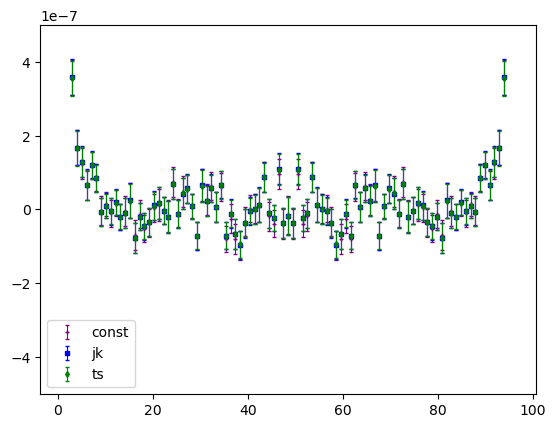

In [126]:
t= np.linspace(1,96,95)
fig,ax = plt.subplots()
ax.errorbar(t, sig_c_avg[1:], yerr=sig_c_err[1:], marker='+', markersize=3, markeredgecolor= 'purple',ls='', elinewidth=0.8, capsize=1.5, color='purple', label="const")
ax.errorbar(t, sig_jk_avg[1:], yerr=sig_jk_err[1:], marker='s', markersize=3, markeredgecolor= 'blue',ls='', elinewidth=0.8, capsize=1.5, color='blue', label="jk")
ax.errorbar(t, sig_ts_avg[1:], yerr=sig_ts_err[1:], marker='d', markersize=3, markeredgecolor= 'green',ls='', elinewidth=0.8, capsize=1.5, color='green', label="ts")
#ax.errorbar(t, sigma_vacsub_avg[1:], yerr=sigma_vacsub_err[1:], marker='o', markersize=3, ls='', elinewidth=0.8, capsize=1.5, color='red', label="Method 1")
ax.set_ylim(-0.5e-6,0.5e-6)
ax.legend();

### pipi analysis and subtraction

In [61]:
#we are looking to subtract 
# C(t) = <O_i * O_j^{dag}> - 1/Lt \sum_{t_src=0}^{L_t-1} <O_i(t+t_src)><O_j(t_src)>
#where in the vev values, the operators with a secondary source are defined with the secondary pioint behind it
#so we need to shift the "sink" operators by 5 timeslices for a Delta of 5. 
#inputs are the 2pt function data and vev data for a given expression. The result should be some C(t), where we have some
#remaining time dependence, based on t_sep. 
def vac_sub(C2pt_jk, Cvev1_jk, Cvev2_jk,Delta):
    Csub_jk = np.zeros_like(C2pt_jk)
    nblks = C2pt_jk.shape[0]
    t_size = Cvev1_jk.shape[-1]
    tsep_max = C2pt_jk.shape[1]
    for jk in range(nblks):
        S = np.zeros(tsep_max,dtype=np.complex128)
        for tsep in range(tsep_max):
            s = 0.0
            for tsrc in range(t_size):
                t_1 = (tsep + tsrc + Delta) % t_size
                s += Cvev1_jk[jk, t_1] * Cvev2_jk[jk,tsrc]

            S[tsep] = (s*96)
            #print(S[tsep])

            Csub_jk[jk,tsep] = C2pt_jk[jk,tsep] - s*96 #(s*48)

    #subtraction term should be very constant
    sub_std = np.std(S[:])
    print(S[0])
    print(f"Subtraction term standard deviation: {sub_std}")
    #assert sub_std < 1e-6, "Subtraction term not constant, standard deviation greater than 1e-6"
            
    return Csub_jk

In [62]:
#specific for a (ncf, nexp, nt) shape, only pipi terms
def pipi_corr_sum(type_data, ntype, nOp):
    ncf = type_data.shape[0]
    nexp = type_data.shape[1]
    nt = type_data.shape[2]
    C_sum = np.zeros((ncf, nOp, nOp, nt),dtype=np.complex128)

    for i in range(nOp):
        for j in range(nOp):
            C_d = np.zeros((ncf, nt),dtype=np.complex128)
            for d in range(ntype):
                C_d[:,:] += type_data[:,(i*4 + j)*4 + 4 + 1 + d ,:]

            C_sum[:,i,j,:] = C_d[:,:]

    return C_sum

def corr_sum_ind(type_data, ntype_pi_sig, ntype_pipi, nOp):
    total_volume = (48*48*48*96) #lattice size
    ncf = type_data.shape[0]
    nexp = type_data.shape[1]
    nexp_pipi = 16
    nexp_pi_sig = 8
    nt = type_data.shape[2]
    C_sum = np.zeros((ncf, nOp, nOp, nt),dtype=np.complex128)

    #for cf in range(ncf):

    #sigma-sigma data only has one entry
    C_sum[:,1,1,:] = type_data[:,1,:]

    k = 0
    l = 0
    for i in range(nOp-1):
        if i >= 1:
            k = i + 1
        else:
            k = i
        
        C_c1 = np.zeros((ncf,nt),dtype=np.complex128) #holds summed correlator for cross terms
        C_c2 = np.zeros((ncf,nt),dtype=np.complex128) #holds summed correlator for cross terms

        #iterate over the two expressions for each cross term, sum them into the intermediate array, and then place them in the 5x5 correlator matrix. 
        for d in range(ntype_pi_sig):
            C_c1[:,:] += type_data[:,i*4*5 + 1 + d + 1,:]
        for d in range(ntype_pi_sig):
            C_c2[:,:] += type_data[:, i*4*5 + 3 + d + 1,:]
                
        #C_sum[k,1,:,:] = (C_c1[:,:]/type_data[:,0,:])*total_volume
        #C_sum[1,k,:,:] = (C_c2[:,:]/type_data[:,0,:])*total_volume

        C_sum[:,k,1,:] = (C_c1[:,:]/(total_volume**2))
        C_sum[:,1,k,:] = (C_c2[:,:]/(total_volume**2))

        for j in range(nOp-1):
            if j >= 1:
                l = j + 1
            else: 
                l = j

            C_d = np.zeros((ncf, nt),dtype=np.complex128)
            for d in range(ntype_pipi):
                C_d[:,:] += type_data[:,(i*4 + j)*4 + 4*(i+1) + 1 + d + 1 ,:]

            print(f"k: {k}, l: {l}")

            #C_sum[k,l,:,:] = (C_d[:,:]/type_data[:,0,:])*total_volume
            C_sum[:,k,l,:] = (C_d[:,:])#/(total_volume**2))

    return C_sum

In [144]:
ld_1 = q.load_lat_data(dst_corr_p + f"/traj-1102/pipi_corr_psnk_psrc.lat")
ld_1.info()[0][2]

['< 1 >  exprs[0]',
 '< sigma^dag(0) * sigma(-tsep) >  exprs[1]',
 '< wf_src(0) * sigma^dag(0) * pipi_i00(-tsep) > (ADT1_pps)  exprs[2]',
 '< wf_src(0) * sigma^dag(0) * pipi_i00(-tsep) > (ADT2_pps)  exprs[3]',
 '< wf_src(0) * sigma^dag(0) * pipi_i00(-tsep) > (ADT1_spp)  exprs[4]',
 '< wf_src(0) * sigma^dag(0) * pipi_i00(-tsep) > (ADT2_spp)  exprs[5]',
 '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[6]',
 '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT2)  exprs[7]',
 '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT3)  exprs[8]',
 '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT4)  exprs[9]',
 '< wf_snk(1) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[10]',
 '< wf_snk(1) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT2)  exprs[11]',
 '< wf_snk(1) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT3)  exprs[12]',
 '< wf_snk(1) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) 

In [131]:
dst_corr_p = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-p"
dst_vev_p = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-p"
#dst_Vsub = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-V"

dst_list_corr_p = []
dst_list_vev_p = []
dst_list_Vsub = []

corr_data_p = []
vev_data_p = []
Vsub_data = []
tsep_max = 20

for traj in range(1102, 1493, 10):
    #print(traj)
    dst_p = dst_corr_p + f"/traj-{traj}/pipi_corr_psnk_psrc.lat"
    dst_vp = dst_vev_p + f"/traj-{traj}/pipi_vev.lat"
    #dst_Vsub = dst_Vsub + f"/traj-{traj}/vac_corr_psnk_psrc.lat"
    #Vsub_data.append(q.load_lat_data(dst_Vsub).to_numpy())

    corr_data_p.append(q.load_lat_data(dst_p).to_numpy())
    vev_data_p.append(q.load_lat_data(dst_vp).to_numpy())  

for traj in range(1505, 1636, 10):
#    print(traj)
    dst_p = dst_corr_p + f"/traj-{traj}/pipi_corr_psnk_psrc.lat"
    dst_vp = dst_vev_p + f"/traj-{traj}/pipi_vev.lat"

    #dst_Vsub = dst_Vsub + f"/traj-{traj}/vac_corr_psnk_psrc.lat"
    #Vsub_data.append(q.load_lat_data(dst_Vsub).to_numpy())

    corr_data_p.append(q.load_lat_data(dst_p).to_numpy())
    vev_data_p.append(q.load_lat_data(dst_vp).to_numpy())

for traj in range(1705, 2176, 10):
    #print(traj)
    if traj==2035 or traj==2075:
        continue
    else:
        dst_p = dst_corr_p + f"/traj-{traj}/pipi_corr_psnk_psrc.lat"
        dst_vp = dst_vev_p + f"/traj-{traj}/pipi_vev.lat"

        #dst_Vsub = dst_Vsub + f"/traj-{traj}/vac_corr_psnk_psrc.lat"
        #Vsub_data.append(q.load_lat_data(dst_Vsub).to_numpy())
    
        corr_data_p.append(q.load_lat_data(dst_p).to_numpy())
        vev_data_p.append(q.load_lat_data(dst_vp).to_numpy())

for traj in range(975, 1096, 10):
    #print(traj)
    dst_p = dst_corr_p + f"/traj-{traj}/pipi_corr_psnk_psrc.lat"
    dst_vp = dst_vev_p + f"/traj-{traj}/pipi_vev.lat"

    #dst_Vsub = dst_Vsub + f"/traj-{traj}/vac_corr_psnk_psrc.lat"
    #Vsub_data.append(q.load_lat_data(dst_Vsub).to_numpy())

    corr_data_p.append(q.load_lat_data(dst_p).to_numpy())
    vev_data_p.append(q.load_lat_data(dst_vp).to_numpy())

ncf_pipi = len(corr_data_p)
ncf_vev = len(vev_data_p)

pipi_arr_p = np.array(corr_data_p)
vev_arr_p = np.array(vev_data_p)
#Vsub_arr = np.array(Vsub_data)

In [133]:
print(pipi_arr_p.shape)
print(vev_arr_p.shape)
#print(Vsub_arr.shape)

(113, 82, 20)
(113, 11, 96)


In [298]:
sigma_corr = pipi_arr_p[:,1,:]

sigma_jks = jackblocks_all(sigma_corr,omit=[])

sigma_avg, sigma_err = jack_all(sigma_jks.real)

<ErrorbarContainer object of 3 artists>

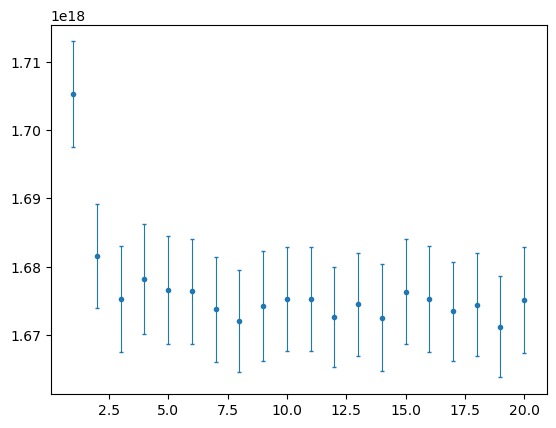

In [301]:
ts=np.linspace(1,20,20)
fig, ax = plt.subplots()
ax.errorbar(ts, sigma_avg, yerr=sigma_err, marker='.', ls='', elinewidth=0.8, capsize=1.5)

In [6]:
counter_vev = vev_arr_p[:,0,:]
sigma_vev = vev_arr_p[:,1,:]
print(sigma_vev.shape)
tol=1e-12

#sum over time
counter_const = np.sum(counter_vev,axis=-1)
sigma_const = np.sum(sigma_vev,axis=-1)

counter_const_jk = jackblocks_all(counter_const,omit=[])
sigma_const_jk = jackblocks_all(sigma_const,omit=[])

sig_const_norm = np.divide(sigma_const_jk,counter_const_jk,where=(counter_const_jk>tol))

sig_const_avg,sig_const_err = jack_all(sig_const_norm)
print(sig_const_avg.shape)
#np.save("sig_const_avg.npy",sig_const_avg)

#time left free
counter_vev_jk = jackblocks_all(counter_vev,omit=[])
sigma_vev_jk   = jackblocks_all(sigma_vev,omit=[])
print(sigma_vev_jk.shape)

tol = 1e-12
sigma_norm = np.divide(sigma_vev_jk,counter_vev_jk,where=(counter_vev_jk>tol))
print(sigma_norm.shape)
#np.save("sigma_jks.npy",sigma_norm)

sig_avg,sig_err = jack_all(sigma_norm)
#np.save("sigma_avg.npy", sig_avg)
print(sig_avg.shape)

(113, 96)
()
(113, 96)
(113, 96)
(96,)


In [9]:
print(sig_const_avg)
print(np.mean(sig_avg))
print(np.mean(sigma_norm[0]))

(-0.010807607889868504-6.393925886620131e-07j)
(-0.010807419087266693-6.144337961102356e-07j)
(-0.010807019327797804-6.220011826081447e-07j)


<ErrorbarContainer object of 3 artists>

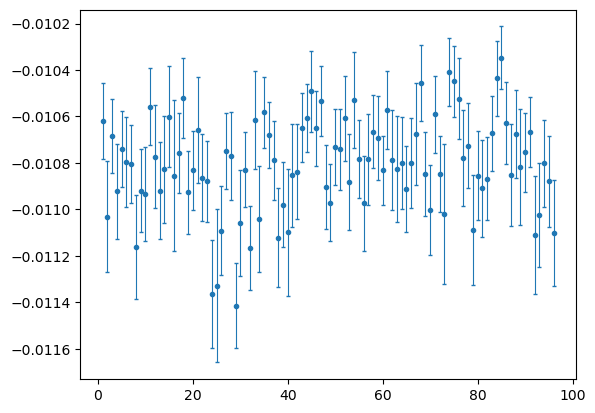

In [316]:
ts=np.linspace(1,96,96)
fig,ax=plt.subplots()
ax.errorbar(ts, sig_avg, yerr=sig_err, marker='.', ls='', elinewidth=0.8, capsize=1.5)

In [66]:
sig_vac = construct_V(sigma_vev_jk,Delta=0)

sig_vac_avg, sig_vac_err = jack_all(sig_vac.real)

fig, ax = plt.subplots()
ax.errorbar(ts, sig_vac_avg, yerr=sig_vac_err, marker='.', ls='', elinewidth=0.8, capsize=1.5)
#ax.set_ylim(0,0.02)

NameError: name 'construct_V' is not defined

We have data for every diagram type for each two point function, including these $\langle O_{\pi\pi} \sigma^{\dagger} \rangle$ cross terms. I will start by reconstructing the full correlator from the individual types, summing over types on the configuration level. Then, I will plot the jackknife blocks of each diagram type, along with the full correlator. I will then construct a 5x5 matrix with this and the sigma two point function, enacting the subtraction on each correlator in this matrix. From here I will do a GEVP to extract the two pion energies. 

#### Correlator sum and plots by diagram type

Cross terms have two diagrams, pipi correlators have four. For each momentum projection, we do the all cross terms first, since only one operator is projected, then we iterate over source momenta to do the projection on the pipi operators. the first expression is always this counter index, which we will use to normalize the data, then expressions 1 and 2 correspond to $\langle O_{\pi\pi,0}(t) \ \sigma^{\dagger}(0) \rangle$ rectangle and vacuum diagram respectively, and 3 and 4 correspond to the other cross term, $\langle \sigma(t) O_{\pi\pi,0}^{\dagger}(0) \rangle$ terms, same diagram order. Following this, we have the first set of pipi operators, where each two pion operator is projected to zero back to back pion momentum, $\langle O_{\pi\pi,0}(t) \ O_{\pi\pi,0}^{\dagger}(0) \rangle$. This means expression 5 - 8 are the vacuum (V), Direct (D), Cross (C), and Rectangle (R) diagrams respectively. We then iterate over sink momenta projections, meaning the next four expressions, 9-12 are the same diagram order for the term $\langle O_{\pi\pi,1}(t) \ O_{\pi\pi,0}^{\dagger}(0) \rangle$, where the 1 subscript denotes the back to back (0,0,1) momentum projections of each individual pion, and equivalent momentum configurations are averaged over. Following this, expressions 13-16 are $\langle O_{\pi\pi,2}(t) \ O_{\pi\pi,0}^{\dagger}(0) \rangle$ for the (0,1,1) projection, and expressions 17-20 are $\langle O_{\pi\pi,3}(t) \ O_{\pi\pi,0}^{\dagger}(0) \rangle$ for the (1,1,1) projection. Then the cycle repeats, starting again with the $\langle O_{\pi\pi,0}(t) \ \sigma^{\dagger}(0) \rangle$ cross terms, where the source momentum projection is now to the (0,0,1) momentum configuration. Following this expression structure we can construct arrays of any combination we want. 

In [67]:
nOp = 5
ntype_pp = 4
ntype_sp = 2
tsep_max = 20
nt = 96

#pipi_type_arr = np.zeros((nOp, nOp, ntype_pp + 1, ncf, tsep_max),dtype=np.complex128)
#ps_type_arr = np.zeros((nOp, ncf, tsep_max), dtype=np.complex128)

In [68]:
C_pipi_p_sum2 = corr_sum_ind(pipi_arr_p,ntype_sp, ntype_pp, nOp)

k: 0, l: 0
k: 0, l: 2
k: 0, l: 3
k: 0, l: 4
k: 2, l: 0
k: 2, l: 2
k: 2, l: 3
k: 2, l: 4
k: 3, l: 0
k: 3, l: 2
k: 3, l: 3
k: 3, l: 4
k: 4, l: 0
k: 4, l: 2
k: 4, l: 3
k: 4, l: 4


In [197]:
C_pipi_p_sum2.shape

(113, 5, 5, 20)

In [ ]:
#put the sigma data in the matrix

In [190]:
C_pipi_p_sum2[0,0,0,:]

array([1.10374781e+11-7.70928603e+07j, 8.91853188e+10-6.50663978e+07j,
       8.25792714e+10-1.14331573e+08j, 7.86880050e+10-4.55192511e+07j,
       7.36988109e+10-5.24769157e+07j, 7.29176068e+10-8.07908155e+07j,
       7.09032458e+10-3.55752734e+07j, 6.91039236e+10-1.17477172e+08j,
       6.69327469e+10-5.89602820e+07j, 6.77439054e+10-3.07033108e+07j,
       6.58954933e+10-5.94037081e+07j, 6.58179978e+10-4.04156525e+07j,
       6.51724058e+10-6.08272792e+07j, 6.14605181e+10-7.88494603e+07j,
       6.50574810e+10-3.11676262e+07j, 6.72830471e+10-5.35334213e+07j,
       6.16847110e+10-6.87931433e+07j, 6.55859017e+10-6.16490115e+07j,
       6.07200216e+10-9.42741184e+07j, 6.09422301e+10-5.79757230e+07j])

In [73]:
C_pipi_sum_jks = jackblocks_all(C_pipi_p_sum2,omit=[])

C_pipi_sum_avg, C_pipi_sum_err = jack_all(C_pipi_sum_jks.real)
print(C_pipi_sum_avg.shape)

(5, 5, 20)


In [135]:
pipi_arr_p_jks = jackblocks_all(pipi_arr_p, omit=[])
nexpr = pipi_arr_p_jks.shape[1]

pipi_p_type_avg = np.zeros((nexpr, tsep_max))
pipi_p_type_err = np.zeros((nexpr, tsep_max))
for i in range(nexpr):
    pipi_p_type_avg[i,:], pipi_p_type_err[i,:] = jack_all(pipi_arr_p_jks[:,i,:].real)

In [136]:
print(pipi_arr_p_jks.shape)

(113, 82, 20)


In [ ]:
pipi_V_avg = np.array([pipi_p_type_avg[6],pipi_p_type_avg[30],pipi_p_type_avg[54],pipi_p_type_avg[78]])
pipi_V_err = np.array([pipi_p_type_err[6],pipi_p_type_err[30],pipi_p_type_err[54],pipi_p_type_err[78]])

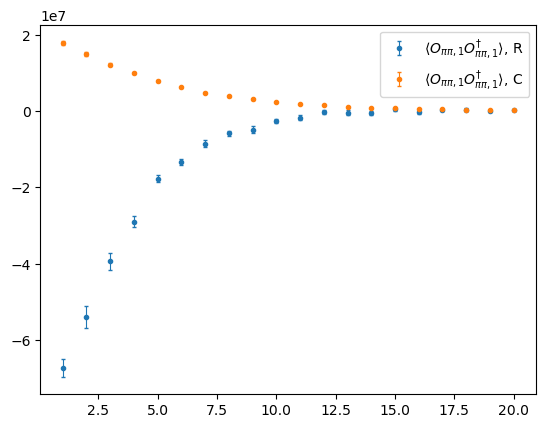

In [168]:
tsep = np.linspace(1,20,20)
fig, ax = plt.subplots()
#ax.errorbar(tsep, C_pipi_sum_avg[0,0,:], yerr=C_pipi_sum_err[0,0,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$")
#ax.errorbar(tsep, C_pipi_sum_avg[1,1,:], yerr=C_pipi_sum_err[1,1,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma \sigma^{\dagger} \rangle$")
#ax.errorbar(tsep, C_pipi_sum_avg[2,2,:], yerr=C_pipi_sum_err[2,2,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$")
#ax.errorbar(tsep, C_pipi_sum_avg[3,3,:], yerr=C_pipi_sum_err[3,3,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 2} O_{\pi\pi, 2}^{\dagger} \rangle$")
#ax.errorbar(tsep, C_pipi_sum_avg[4,4,:], yerr=C_pipi_sum_err[4,4,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 3} O_{\pi\pi, 3}^{\dagger} \rangle$")

#ax.errorbar(tsep, pipi_p_type_avg[6,:], yerr=pipi_p_type_err[6,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, V")
#ax.errorbar(tsep, pipi_p_type_avg[7,:], yerr=pipi_p_type_err[7,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, R")
#ax.errorbar(tsep, pipi_p_type_avg[8,:], yerr=pipi_p_type_err[8,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, D")
#ax.errorbar(tsep, pipi_p_type_avg[9,:], yerr=pipi_p_type_err[9,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, C")

#ax.errorbar(tsep, pipi_p_type_avg[30,:], yerr=pipi_p_type_err[30,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, V")
ax.errorbar(tsep, pipi_p_type_avg[31,:], yerr=pipi_p_type_err[31,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, R")
#ax.errorbar(tsep, pipi_p_type_avg[32,:], yerr=pipi_p_type_err[32,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, D")
ax.errorbar(tsep, pipi_p_type_avg[33,:], yerr=pipi_p_type_err[33,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, C")

#ax.errorbar(tsep, pipi_p_type_avg[54,:], yerr=pipi_p_type_err[54,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, V")
#ax.errorbar(tsep, pipi_p_type_avg[55,:], yerr=pipi_p_type_err[55,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, D")
#ax.errorbar(tsep, pipi_p_type_avg[55,:], yerr=pipi_p_type_err[55,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, C")
#ax.errorbar(tsep, pipi_p_type_avg[56,:], yerr=pipi_p_type_err[56,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, R")

#ax.errorbar(tsep, pipi_p_type_avg[79,:], yerr=pipi_p_type_err[79,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, V")

#ax.set_ylim(7.5e9, 9.5e9)
ax.legend()

#### Matrix construction and vacuum subtraction

The correlator matrix has been constructed already, we must construct another matrix of the same shape to hold the vacuum expectation values, then then do the subtraction matrix wise. We have 11 expressions in the vev array, the first being the counter, the next two being the sigma vevs, $\langle \sigma(t_{src}) \rangle$ and $\langle \sigma^{\dagger}(t_{src}) \rangle$. Then we alternate between undaggered and daggered vevs for each momentum projection. That is expressions 4 and 5 are $\langle O_{\pi\pi,0}(t_{src}) \rangle$ and $\langle O_{\pi\pi,0}^{\dagger}(t_{src}) \rangle$ and so on. 

In [69]:
vev_count = vev_arr_p[:,0,:]
vev_sigma = vev_arr_p[:,1:3,:]
vev_pipi = vev_arr_p[:,3:,:]

In [70]:
vev_pipi.shape

(113, 8, 96)

In [1102]:
vev_gs = vev_arr_p[:,3,:]

In [1105]:
np.std(sub_mat[0,0,:24])

np.float64(22061768.940747518)

In [116]:
sub_mat = subtraction_matrix(vev_arr_p)

In [112]:
#implementation of the vacuum subtraction term. This constructs the subtraction term for each element of the correlator mat
#the first sigma entry is the <sigma>, followed by the <sigma^\dagger>, the same structure for each momentum projection. 
def subtraction_matrix(vev_arr):
    ncf = vev_arr.shape[0]
    nexpr = vev_arr.shape[1]
    nt = vev_arr.shape[2]
    nOp = (nexpr-1)//2
    
    #normalize by the counts
    vev_count = vev_arr[:,0,:]
    vev_norm = np.zeros_like(vev_arr)
    
    for expr in range(nexpr):
        vev_norm[:, expr, :] = vev_arr[:,expr,:]#/vev_count

    #vev_norm_jk = jackblocks_expr(vev_norm, omit=[])
    #vev_norm_avg, vev_norm_err = jack(vev_norm_jk)

    #construct the subtraction term
    vev_mat = np.zeros((ncf, nOp, nOp, nt),dtype=np.complex128)
    
    for i in range(nOp):
        for j in range(nOp):
            Delta = 5
            if i == 0:
                vev1= vev_norm[:,i+3,:] 
            elif i == 1:
                Delta = 0
                vev1 = vev_norm[:,1,:]
            elif i > 1:
                vev1 = vev_norm[:, (i-1)*2+3,:]

            if j == 0:
                vev2 = vev_norm[:,j+4,:]
            elif j == 1:
                Delta=0
                vev2 = vev_norm[:,2,:]
            elif j > 1: 
                vev2 = vev_norm[:,(j-1)*2+4,:]

            
            vev_mat[:,i,j,:] = sub_term_conf(vev1, vev2, Delta)
            #configuration index gone
    
    return vev_mat
    


#function that calculates one subtraction term given the two vevs it needs to compute the term. See the 2023 A2A pion scattering paper eq. 14
# S(t) = 1/L_t \sum_{t_src = 1}^{L_t-1} <O_i(t + t_src)> <O_j(t_src)^{\dagger}>
#Delta is an offset, necessary for the pipi * pipi terms since the second source and second sink are in the same direction. For now,
#any pipi*pipi term needs Delta=5, and any term involving the sigma needs Delta=0. 
def sub_term(Cvev1_jk, Cvev2_jk,Delta):
    nblks = Cvev1_jk.shape[0]
    t_size = Cvev1_jk.shape[-1]
    print(Cvev1_jk.shape)
    print(Cvev2_jk.shape)

    S = np.zeros((nblks,t_size),dtype=np.complex128) #this will hold the full subtraction term for each jackknife block
    for jk in range(nblks):
        for tsep in range(t_size):
            s = 0.0
            for tsrc in range(t_size):
                t_1 = (tsep + tsrc + Delta) % t_size
                s += Cvev1_jk[jk, t_1] * Cvev2_jk[jk,tsrc]

            S[jk,tsep] = s/t_size
            #print(S[tsep])

    #subtraction term should be very constant
    sub_std = np.std(S[:])
    print(f"Subtraction term standard deviation: {sub_std}")
    #assert sub_std < 1e-6, "Subtraction term not constant, standard deviation greater than 1e-6"
            
    return S

#subtraction on a configuration by configuration basis
def sub_term_conf(Cvev1, Cvev2,Delta):
    ncf = Cvev1.shape[0]
    t_size = Cvev1.shape[-1]
    #print(Cvev1_jk.shape)
    #print(Cvev2_jk.shape)
    
    S = np.zeros((ncf,t_size),dtype=np.complex128) #this will hold the full subtraction term for each jackknife block
    #S = np.zeros((t_size),dtype=np.complex128)
    for tsep in range(t_size):
        s = np.zeros((ncf),dtype=np.complex128)
        for tsrc in range(t_size):
            t_1 = (tsep + tsrc + Delta) % t_size
            s[:] += Cvev1[:,t_1] * Cvev2[:,tsrc]

        S[:,tsep] = (s[:])
        #print(S[tsep])

    #subtraction term should be very constant
    #sub_std = np.std(S[:])
    #print(f"Subtraction term standard deviation: {sub_std}")
    #assert sub_std < 1e-6, "Subtraction term not constant, standard deviation greater than 1e-6"
            
    return S
    

In [117]:
sub_mat.shape

(113, 5, 5, 96)

In [113]:
C_pipi_p_sum2.shape

(113, 5, 5, 20)

In [221]:
#raw subtraction - subtraction before ensemble average
C_sub_raw = np.zeros_like(C_pipi_p_sum2)

sub_mat = subtraction_matrix(vev_arr_p) #matrix of vev products for the raw vev data
C_sub_raw = C_pipi_p_sum2 - sub_mat[:,:,:,:20]

C_sub_raw_jk = jackblocks_all(C_sub_raw,omit=[])
C_sub_raw_avg, C_sub_raw_err = jack_all(C_sub_raw_jk)
print(C_sub_raw_avg.shape)

(5, 5, 20)


In [114]:
#subtraction with jackblocked data
C_sub_jk = np.zeros_like(C_pipi_sum_jks)

vev_arr_jk= jackblocks_all(vev_arr_p,omit=[])
sub_mat_jk = subtraction_matrix(vev_arr_jk)

C_sub_jk = C_pipi_sum_jks - sub_mat_jk[:,:,:,:20]

C_sub_avg, C_sub_err= jack_all(C_sub_jk.real)
print(C_sub_avg.shape)

(5, 5, 20)


In [119]:
n = 0
ncf = sub_mat.shape[2]
sub_corr_0 = np.zeros((ncf, 20),dtype=np.complex128)
sub_corr_1 = np.zeros((ncf, 20),dtype=np.complex128)
sub_corr_2 = np.zeros((ncf, 20),dtype=np.complex128)
sub_corr_3 = np.zeros((ncf, 20),dtype=np.complex128)
for cf in range(ncf):
    sub_corr_0[cf,:] = C_pipi_p_sum2[0,0,cf,:] - sub_mat[0,0,cf,:20]
    sub_corr_1[cf,:] = C_pipi_p_sum2[2,2,cf,:] - sub_mat[2,2,cf,:20]
    sub_corr_2[cf,:] = C_pipi_p_sum2[3,3,cf,:] - sub_mat[3,3,cf,:20]
    sub_corr_3[cf,:] = C_pipi_p_sum2[4,4,cf,:] - sub_mat[4,4,cf,:20]

sub_corr_0_jk = jackblocks_all(sub_corr_0,omit=[])
sub_corr_1_jk = jackblocks_all(sub_corr_1,omit=[])
sub_corr_2_jk = jackblocks_all(sub_corr_2,omit=[])
sub_corr_3_jk = jackblocks_all(sub_corr_3,omit=[])

sub_corr_0_avg, sub_corr_0_err = jack_all(sub_corr_0_jk.real)
sub_corr_1_avg, sub_corr_1_err = jack_all(sub_corr_1_jk.real)
sub_corr_2_avg, sub_corr_2_err = jack_all(sub_corr_2_jk.real)
sub_corr_3_avg, sub_corr_3_err = jack_all(sub_corr_3_jk.real)

print(sub_corr_0_avg.shape)

(20,)


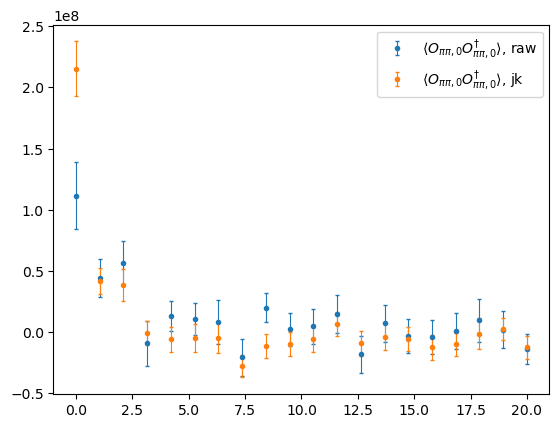

In [236]:
tsep = np.linspace(0,20,20)
fig, ax = plt.subplots()

#ax.errorbar(tsep, C_sub_raw_avg[0,0,:].real, yerr=C_sub_raw_err[0,0,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, raw")
#ax.errorbar(tsep, C_sub_raw_avg[2,2,:].real, yerr=C_sub_raw_err[2,2,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, raw")
#ax.errorbar(tsep, C_sub_raw_avg[3,3,:].real, yerr=C_sub_raw_err[3,3,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, raw")
#ax.errorbar(tsep, C_sub_raw_avg[4,4,:].real, yerr=C_sub_raw_err[4,4,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, raw")

#ax.errorbar(tsep, C_sub_avg[0,0,:].real, yerr=C_sub_err[0,0,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, jk")
#ax.errorbar(tsep, C_sub_avg[2,2,:].real, yerr=C_sub_err[2,2,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, jk")
#ax.errorbar(tsep, C_sub_avg[3,3,:].real, yerr=C_sub_err[3,3,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, jk")
#ax.errorbar(tsep, C_sub_avg[4,4,:].real, yerr=C_sub_err[4,4,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 0} O_{\pi\pi, 0}^{\dagger} \rangle$, jk")

#ax.set_yscale("log")
ax.legend();
#ax.set_ylim(-1e-6, 1e-6)

#### Leftovers

In [113]:
nexpr=5
pi_sigma_arr = np.zeros((ncf_pipi-1,nexpr,tsep_max),dtype=np.complex128)
sigma_pi_arr = np.zeros((ncf_pipi-1,nexpr,tsep_max),dtype=np.complex128)

pi_sigma_arr[:,:,:] = sigpi_arr[:,:,:,0]
sigma_pi_arr[:,:,:] = sigpi_arr[:,:,:,1]

In [114]:
pipi_type_jk = jackblocks_expr(pipi_type_arr,omit=[])
vev2_arr_jk = jackblocks_expr(vev2_arr, omit=[])
pipi_type_avg, pipi_type_err = jack(pipi_type_jk)

In [115]:
pipi_arr_jk = jackblocks_expr(pipi_arr,omit=[])
pi_sig_jk = jackblocks_expr(pi_sigma_arr,omit=[])
sig_pi_jk = jackblocks_expr(sigma_pi_arr,omit=[])
vev_arr_jk = jackblocks_expr(vev_arr, omit=[])

In [116]:
pipi_arr_jk.shape

(23, 17, 19)

In [117]:
pipi_type_arr.shape

(23, 65, 19)

In [118]:
C_total = full_corr_sum(pipi_type_arr, 4, 4)
C_total.shape

(4, 4, 23, 19)

In [89]:
C_total_jks = jackblocks_mat(C_total,omit=[])
C_total_jks.shape

(4, 4, 23, 19)

In [119]:
Ct_000_avg, Ct_000_err = jack(C_total_jks[0,0,:,:])
Ct_001_avg, Ct_001_err = jack(C_total_jks[1,1,:,:])
Ct_011_avg, Ct_011_err = jack(C_total_jks[2,2,:,:])
Ct_111_avg, Ct_111_err = jack(C_total_jks[3,3,:,:])
Ct_000_avg.shape

(19,)

In [136]:
np.linspace(2,20,19)

array([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.,
       15., 16., 17., 18., 19., 20.])

In [120]:
pipi_avg, pipi_err = jack(pipi_arr_jk)
pi_sig_avg, pi_sig_err = jack(pi_sig_jk)
sig_pi_avg, sig_pi_err = jack(sig_pi_jk)
vev_avg, vev_err = jack(vev_arr_jk)

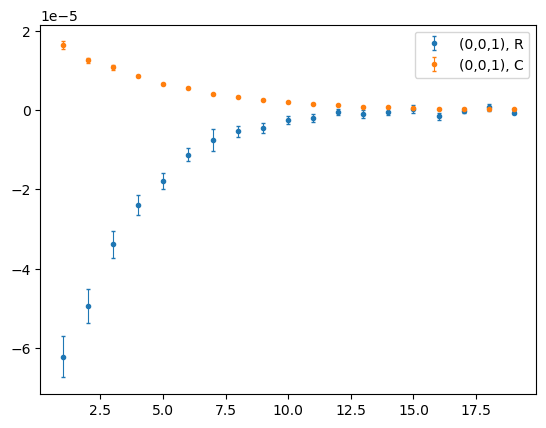

In [143]:
t_sep = np.linspace(1,19,19)
fig, ax = plt.subplots()
#ax.errorbar(t_sep, pipi_avg[1,:].real, yerr=pipi_err[1,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), total")
#ax.errorbar(t_sep, pipi_avg[6,:].real, yerr=pipi_err[6,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,1)")
#ax.errorbar(t_sep, pipi_avg[11,:].real, yerr=pipi_err[11,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,1,1)")
#ax.errorbar(t_sep, pipi_avg[16,:].real, yerr=pipi_err[16,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(1,1,1)")

#ax.errorbar(t_sep, pipi_type_avg[1,:].real, yerr=pipi_type_err[1,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), V")
#ax.errorbar(t_sep, pipi_type_avg[2,:].real, yerr=pipi_type_err[2,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), R")
#ax.errorbar(t_sep, pipi_type_avg[3,:].real, yerr=pipi_type_err[3,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), D")
#ax.errorbar(t_sep, pipi_type_avg[4,:].real, yerr=pipi_type_err[4,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), C")

#ax.errorbar(t_sep, pipi_type_avg[5,:].real, yerr=pipi_type_err[1,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), V")
#ax.errorbar(t_sep, pipi_type_avg[6,:].real, yerr=pipi_type_err[2,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), R")
#ax.errorbar(t_sep, pipi_type_avg[7,:].real, yerr=pipi_type_err[3,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), D")
#ax.errorbar(t_sep, pipi_type_avg[8,:].real, yerr=pipi_type_err[4,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), C")

#ax.errorbar(t_sep, pipi_type_avg[21,:].real, yerr=pipi_type_err[21,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,1), V")
#ax.errorbar(t_sep, pipi_type_avg[22,:].real, yerr=pipi_type_err[22,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,1), R")
#ax.errorbar(t_sep, pipi_type_avg[23,:].real, yerr=pipi_type_err[23,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,1), D")
#ax.errorbar(t_sep, pipi_type_avg[24,:].real, yerr=pipi_type_err[24,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,1), C")

#ax.errorbar(t_sep, pipi_type_avg[41,:].real, yerr=pipi_type_err[41,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,1,1), V")
#ax.errorbar(t_sep, pipi_type_avg[42,:].real, yerr=pipi_type_err[42,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,1,1), R")
#ax.errorbar(t_sep, pipi_type_avg[43,:].real, yerr=pipi_type_err[43,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,1,1), D")
#ax.errorbar(t_sep, pipi_type_avg[44,:].real, yerr=pipi_type_err[44,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,1,1), C")

#ax.errorbar(t_sep, pipi_type_avg[61,:].real, yerr=pipi_type_err[61,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(1,1,1), V")
#ax.errorbar(t_sep, pipi_type_avg[62,:].real, yerr=pipi_type_err[62,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(1,1,1), R")
#ax.errorbar(t_sep, pipi_type_avg[63,:].real, yerr=pipi_type_err[63,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(1,1,1), D")
#ax.errorbar(t_sep, pipi_type_avg[64,:].real, yerr=pipi_type_err[64,:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(1,1,1), C")

#ax.errorbar(t_sep, 96*Cs_000_avg[:].real, yerr=Cs_000_err[:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), S")
#ax.errorbar(t_sep, 96*Cs_001_avg[:].real, yerr=Cs_001_err[:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,1), S")
#ax.errorbar(t_sep, 96*Cs_011_avg[:].real, yerr=Cs_011_err[:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,1,1) S")
#ax.errorbar(t_sep, 96*Cs_111_avg[:].real, yerr=Cs_111_err[:].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(1,1,1) S")

#ax.errorbar(t_sep, Ct_000_avg.real, yerr=Ct_000_err.real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,0), sum")
#ax.errorbar(t_sep, Ct_001_avg.real, yerr=Ct_001_err.real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,0,1), sum",)
#ax.errorbar(t_sep, Ct_011_avg.real, yerr=Ct_011_err.real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(0,1,1)")
#ax.errorbar(t_sep, Ct_111_avg.real, yerr=Ct_111_err.real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="(1,1,1)")

#ax.set_ylim(0.00, 0.0001)
ax.legend();

In [ ]:
## nOp = 4
ncf, nexpr, tsep_max = pipi_arr_jk.shape
nt = vev_arr_jk.shape[-1]
pipi_4b4_jk = np.zeros((nOp, nOp, ncf, tsep_max),dtype=np.complex128)
vev1_pipi_jk = np.zeros((nOp, ncf, nt),dtype=np.complex128)
vev2_pipi_jk = np.zeros((nOp, ncf, nt),dtype=np.complex128)
vev1_sigma_jk = np.zeros((ncf, nt),dtype=np.complex128)
vev2_sigma_jk = np.zeros((ncf, nt),dtype=np.complex128)


for op1 in range(nOp):
    for op2 in range(nOp):
        pipi_4b4_jk[op1, op2,:,:] = pipi_arr_jk[:,(op1*4 + op2)+1,:]

vev1_sigma_jk = vev_arr_jk[:,1,:]
vev2_sigma_jk = vev_arr_jk[:,2,:]

#pulling out each independent term from the vev data array to use in a convenient way
for op1 in range(nOp):
    vev1_pipi_jk[op1,:,:] = vev_arr_jk[:,(op1*2 + 0)+3,:]
    vev2_pipi_jk[op1,:,:] = vev_arr_jk[:,(op1*2 + 1)+3,:]

In [46]:
Cs = np.zeros_like(pipi_4b4_jk)

for op1 in range(nOp):
    for op2 in range(nOp):
        Cs[op1,op2,:,:] = vac_sub(pipi_4b4_jk[op1,op2,:,:], vev1_pipi_jk[op1,:,:], vev2_pipi_jk[op2,:,:])
        

(0.05223817705799709-1.1063901758013385e-05j)
Subtraction term standard deviation: 3.5852250648643817e-05
(0.01934285950453711-7.97350838412681e-06j)
Subtraction term standard deviation: 1.4698694301205288e-05
(0.0117328198055314-6.217547086498562e-06j)
Subtraction term standard deviation: 1.049759870729629e-05
(0.0082096369753282-4.597562637654677e-06j)
Subtraction term standard deviation: 8.433976074330121e-06
(0.019327891281218864-8.01433056336936e-06j)
Subtraction term standard deviation: 1.342135124891087e-05
(0.007156814687461551-4.439601954606703e-06j)
Subtraction term standard deviation: 5.718306139121612e-06
(0.004341636212657434-3.188302198096012e-06j)
Subtraction term standard deviation: 4.1595433677675305e-06
(0.0030375228743284985-2.3347321092043223e-06j)
Subtraction term standard deviation: 3.220698741427413e-06
(0.011720590843092075-6.2542708780054236e-06j)
Subtraction term standard deviation: 9.63189784361376e-06
(0.004339808503689795-3.2521607395501152e-06j)
Subtractio

In [1015]:
nt

96

In [49]:
tsep = 19
Cs_avg = np.zeros((nOp, nOp, tsep),dtype=np.complex128)
Cs_err = np.zeros((nOp, nOp, tsep),dtype=np.complex128)
for i in range(nOp):
    for j in range(nOp):
        Cs_avg[i,j,:], Cs_err[i,j,:] = jack(Cs[i,j,:,:])

In [704]:
Cs_000_avg, Cs_000_err = jack(Cs[0,0,:,:])
Cs_001_avg, Cs_001_err = jack(Cs[1,1,:,:])
Cs_011_avg, Cs_011_err = jack(Cs[2,2,:,:])
Cs_111_avg, Cs_111_err = jack(Cs[3,3,:,:])

In [321]:
(np.sum(vev1_sigma_avg[:])*(total_volume)/(2048))*(np.sum(vev1_sigma_avg[:])*(total_volume)/(2048))/96

np.complex128(14979.502276945987-4.914288940606937j)

In [409]:
vev1_sigma_avg, vev1_sigma_err = jack(vev1_sigma_jk)

In [51]:
pipi_avg.shape

(17, 19)

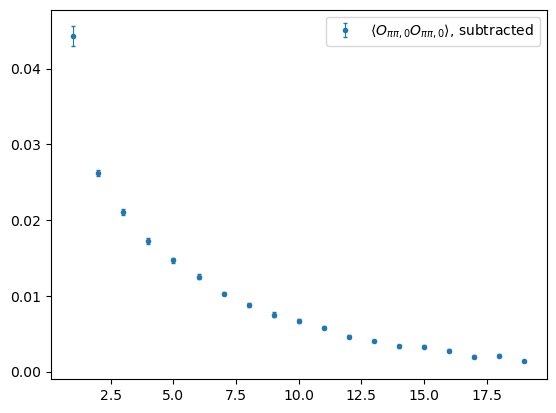

In [149]:
tsep = np.linspace(1,19,19)
t = np.linspace(0,95,96)
fig, ax = plt.subplots()

#ax.errorbar(tsep, pipi_avg[3].real, yerr=pipi_err[3].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,0} O_{\pi\pi,0} \rangle$")
#ax.errorbar(tsep, pipi_avg[6].real, yerr=pipi_err[6].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,0} O_{\pi\pi,0} \rangle$")
#ax.errorbar(tsep, pipi_avg[11].real, yerr=pipi_err[11].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,0} O_{\pi\pi,0} \rangle$")
#ax.errorbar(tsep, pipi_avg[16].real, yerr=pipi_err[16].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,3} O_{\pi\pi,3} \rangle$")

#ax.errorbar(tsep, pipi_avg[3].real, yerr=pipi_err[3].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,0} O_{\pi\pi,0} \rangle$")


ax.errorbar(tsep, Cs_avg[0,0].real, yerr=Cs_err[0,0].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,0} O_{\pi\pi,0} \rangle$, subtracted")
#ax.errorbar(tsep, Cs_avg[0,2].real, yerr=Cs_err[0,2].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,0} O_{\pi\pi,0} \rangle$")
#ax.errorbar(tsep, Cs_avg[1,1].real, yerr=Cs_err[1,1].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,1} O_{\pi\pi,1} \rangle$")
#ax.errorbar(tsep, Cs_avg[2,2].real, yerr=Cs_err[2,2].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,2} O_{\pi\pi,2} \rangle$")
#ax.errorbar(tsep, Cs_avg[3,3].real, yerr=Cs_err[3,3].real, marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,3} O_{\pi\pi,3} \rangle$")

#ax.errorbar(tsep, Cs_001_avg.real, yerr=Cs_001_err.real, marker='.', ls='', elinewidth=0.8, capsize=1.5)
#ax.errorbar(t, vev1_sigma_avg.real, yerr=vev1_sigma_err.real, marker='.', ls='', elinewidth=0.8, capsize=1.5)
#ax.set_ylim(-0.005, -0.001)
ax.legend();

In [150]:
Cs_err[0,0]

array([0.00130526-1.31589751e-06j, 0.00040378+1.32364319e-06j,
       0.00037072+3.17285130e-06j, 0.00038549+1.01060970e-07j,
       0.000335  -6.14691754e-07j, 0.0003042 -3.93860905e-07j,
       0.00022838+1.62343153e-06j, 0.00024611+7.16847112e-07j,
       0.00028483-2.77396313e-07j, 0.00024123+8.42785575e-07j,
       0.00022034+4.71339837e-07j, 0.00018259+1.09382343e-06j,
       0.00019223-6.39832812e-07j, 0.00019709+7.97151675e-07j,
       0.0001816 -9.68685008e-07j, 0.00023229-5.90303497e-07j,
       0.00019561+1.22793045e-06j, 0.00020373+6.47631791e-07j,
       0.0001626 +3.19699741e-07j])

### Cross-term anaysis and subtraction

In [974]:
vev_arr_jk.shape
ncf = vev_arr_jk.shape[0]
nt = vev_arr_jk.shape[-1]
pi_vev1_jk = np.zeros((ncf, 4, nt),dtype=np.complex128)
pi_vev2_jk = np.zeros((ncf, 4, nt),dtype=np.complex128)
tsep_max = 19
k=0
for i in range(3,10,2):
    pi_vev1_jk[:,k,:] = vev_arr_jk[:,i,:]
    pi_vev2_jk[:,k,:] = vev_arr_jk[:,i+1,:]
    k+=1

In [975]:
pi_vev1_jk.shape

(50, 4, 96)

In [996]:
sig_pi_jk.shape

(50, 5, 19)

In [997]:
pi_sigma_sub = np.zeros((ncf, 4, tsep_max),dtype=np.complex128)
sigma_pi_sub = np.zeros((ncf, 4, tsep_max),dtype=np.complex128)

for i in range(4):
    pi_sigma_sub[:37, i, : ] = vac_sub(pi_sig_jk[:37,i+1,:], pi_vev1_jk[:37,i,:], sigma_vev_jk[:,0,:])
    sigma_pi_sub[:37, i, : ] = vac_sub(sig_pi_jk[:37,i+1,:], sigma_vev_jk[:,0,:], pi_vev2_jk[:37,i,:])

(0.052792065650751126-1.0601918688293816e-05j)
Subtraction term standard deviation: 2.3034447414163098e-05
(0.05288723612282549-9.64308663683718e-06j)
Subtraction term standard deviation: 3.679478474520772e-05
(0.019503180846059363-7.999754022991518e-06j)
Subtraction term standard deviation: 1.0214082542728667e-05
(0.019547394856299076-7.607045748604213e-06j)
Subtraction term standard deviation: 1.4417034699200013e-05
(0.01181839912423446-6.051943767473601e-06j)
Subtraction term standard deviation: 7.631701598232377e-06
(0.011846167077020946-5.823754006844229e-06j)
Subtraction term standard deviation: 9.858421689337137e-06
(0.008268068466004752-4.717380652772808e-06j)
Subtraction term standard deviation: 7.100723788475187e-06
(0.00829107032615193-4.357356509897343e-06j)
Subtraction term standard deviation: 8.145389788982433e-06


In [998]:
pi_sigma_sub_avg, pi_sigma_sub_err = jack(pi_sigma_sub)
pi_sig_avg, pi_sig_err = jack(pi_sig_jk)

sigma_pi_sub_avg, sigma_pi_sub_err = jack(pi_sigma_sub)
sig_pi_avg, sig_pi_err = jack(pi_sig_jk)

In [1003]:
sigma_pi_sub_avg.shape

(4, 19)

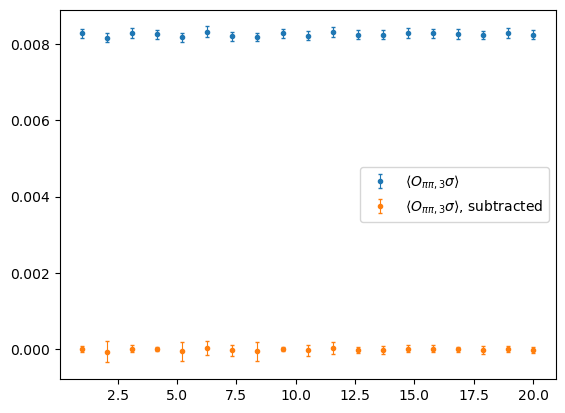

In [1011]:
tsep = np.linspace(1,20,19)
fig, ax = plt.subplots()
#ax.errorbar(tsep, pi_sig_avg[1,:], yerr = pi_sig_err[1,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle  O_{\pi\pi,0} \sigma\rangle$")
#ax.errorbar(tsep, pi_sig_avg[2,:], yerr = pi_sig_err[2,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle  O_{\pi\pi,1} \sigma\rangle$")
#ax.errorbar(tsep, pi_sig_avg[3,:], yerr = pi_sig_err[3,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle  O_{\pi\pi,2} \sigma\rangle$")
ax.errorbar(tsep, pi_sig_avg[4,:], yerr = pi_sig_err[4,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle  O_{\pi\pi,3} \sigma\rangle$")

#ax.errorbar(tsep, sig_pi_avg[1,:], yerr = sig_pi_err[1,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma O_{\pi\pi,0} \rangle$")
#ax.errorbar(tsep, sig_pi_avg[2,:], yerr = sig_pi_err[2,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma O_{\pi\pi,1} \rangle$")
#ax.errorbar(tsep, sig_pi_avg[3,:], yerr = sig_pi_err[3,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma O_{\pi\pi,2} \rangle$")
#ax.errorbar(tsep, sig_pi_avg[4,:], yerr = sig_pi_err[4,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma O_{\pi\pi,3} \rangle$")

#ax.errorbar(tsep, sigma_pi_sub_avg[0,:], yerr = pi_sigma_sub_err[0,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma O_{\pi\pi,0} \rangle$, subtracted")
#ax.errorbar(tsep, sigma_pi_sub_avg[1,:], yerr = pi_sigma_sub_err[1,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma O_{\pi\pi,1} \rangle$, subtracted")
#ax.errorbar(tsep, sigma_pi_sub_avg[2,:], yerr = pi_sigma_sub_err[2,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma O_{\pi\pi,2} \rangle$, subtracted")
#ax.errorbar(tsep, sigma_pi_sub_avg[3,:], yerr = pi_sigma_sub_err[3,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle \sigma O_{\pi\pi,3} \rangle$, subtracted")

#ax.errorbar(tsep, pi_sigma_sub_avg[0,:], yerr = pi_sigma_sub_err[0,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,0} \sigma \rangle$, subtracted")
#ax.errorbar(tsep, pi_sigma_sub_avg[1,:], yerr = pi_sigma_sub_err[1,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,1} \sigma \rangle$, subtracted")
#ax.errorbar(tsep, pi_sigma_sub_avg[2,:], yerr = pi_sigma_sub_err[2,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,2} \sigma \rangle$, subtracted")
ax.errorbar(tsep, pi_sigma_sub_avg[3,:], yerr = pi_sigma_sub_err[3,:],marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi,3} \sigma \rangle$, subtracted")

#ax.set_ylim(-0.001, 0.06)
ax.legend();

### 4x4 GEVP (no sigma)

In [282]:
#changing the 5x5 matrix we have into a 4x4 
nOp = 3

C_sub_4b4 = np.delete(np.delete(C_sub_jk,3,axis=1),3,axis=2)
C_sub_3b3 = np.delete(np.delete(C_sub_4b4,2,axis=1),2,axis=2)

In [283]:
C_sub_3b3.shape

(113, 3, 3, 20)

In [408]:
reg = np.zeros_like(C_sub_3b3[0,0,:,:])
reg += 2e-7

In [409]:
C_sub_4b4_reg = C_sub_4b4 + reg

In [410]:
C_sub_4b4_reg[3,3,0,:]

array([ 1.25901925e-06+1.23462048e-08j,  5.56525057e-07-2.22376930e-09j,
        8.40277192e-07-2.66690755e-09j, -9.18053425e-09+4.41675786e-09j,
        3.42110186e-07-4.26256166e-09j,  2.32283880e-07-8.89630402e-10j,
        2.50615472e-07-3.47836749e-09j,  1.04014035e-08+7.96696945e-09j,
        5.00971988e-07+4.50636921e-09j,  1.47895260e-07-6.76498397e-09j,
        2.45336274e-07-4.19408974e-09j,  3.85534534e-07+9.57220257e-09j,
        6.02351724e-08-1.08980204e-08j,  3.00304004e-07+9.61877654e-09j,
        1.58379343e-07-1.64476937e-09j,  6.18047593e-08-1.12436967e-08j,
        2.17106896e-07+1.41572100e-08j,  3.28627478e-07-3.72422076e-09j,
        2.21509368e-07-3.60541871e-09j,  1.11892665e-07-4.26874868e-09j])

In [284]:
l48I_I0D5 = Ensemble_jks(C_sub_3b3)

In [285]:
l48I_I0D5.jks.shape

(113, 3, 3, 20)

In [307]:
minOp = 0
maxOp = 3
tmin  = 4
tmax  = 10
GEVP(l48I_I0D5, minOp, maxOp, tmin, tmax)

LinAlgError: The leading minor of order 2 of B is not positive definite. The factorization of B could not be completed and no eigenvalues or eigenvectors were computed.

In [462]:
l48I_I0D5.e[82,:,0]

array([0.        , 0.        , 0.80249205, 0.84446565, 0.9190785 ,
       0.84262191, 0.88585551, 0.85413943, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [463]:
t1=2
t2=7
fpD5d25, fcD5d25 = ex_fit_ln(l48I_I0D5.ncf,l48I_I0D5.e,l48I_I0D5.nOp,t1,t2)

n, chi square, dof= 0 (np.float64(0.8895886855539868), np.float64(1.7183307608266178)) 4
p-value= 0.9297438031152454
----------------------------------------
n, chi square, dof= 1 (np.float64(1.0228862376032277), np.float64(1.6170806946837715)) 4
p-value= 0.9109991804750852
----------------------------------------


Energy= 0 0.17256426037849118 0.013884725754364472
----------------------------------------------------
Energy= 1 0.3190977836337024 0.05940208870079596
----------------------------------------------------


/tmp/ipykernel_2714810/3675943357.py:6: RuntimeWarning: invalid value encountered in log
  v,err=jack(-np.log(l48I_I0D5.e[:,tmin:tmax,l]))


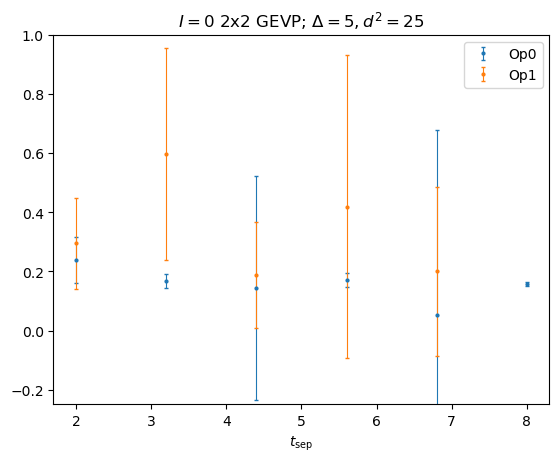

In [465]:
fig5, ax5 = plt.subplots()
a_inv = 1.73
#excited states
t = np.linspace(2,8,6)
for l in range(0,maxOp):
    v,err=jack(-np.log(l48I_I0D5.e[:,tmin:tmax,l]))
    ax5.errorbar(t,v,err,marker='o',linestyle='',elinewidth=0.8,markersize=2,capsize=1.5,label='Op'+str(l))
    v,err=jack(fpD5d25[l,:,0])
    print('Energy=',l,v,err)
    print("----------------------------------------------------")

ax5.set_ylim(-0.25,1)
#ax5.set_xlim(1,14)
ax5.set_xlabel(r"$t_{\text{sep}}$")
ax5.set_title(r"$I=0$ 2x2 GEVP; $\Delta=5, d^2 = 25$")
ax5.legend();

### Improved vacuum subtraction

In [223]:
#dst = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-dc-sub3/traj-1132/pipi_bubble_mom.lat"
#dst = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-phase-avg-D1/traj-1162/pipi_vev_pos_avg.lat"
dst = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-V/traj-1515/vac_corr_psnk_psrc.lat"
#dst_nosub = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-avg-pos/traj-1132/pipi_vev_pos.lat"
ld_pos = q.load_lat_data(dst)
#ld_nosub = q.load_lat_data(dst_nosub)

In [224]:
ld_pos.info()[0][2]

['< 1 >  exprs[0]',
 '< wf_snk(0) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[1]',
 '< wf_snk(0) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0>) * (pipi_i00(-tsep) - <pipi_i0>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[2]',
 '< wf_snk(1) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[3]',
 '< wf_snk(1) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0>) * (pipi_i00(-tsep) - <pipi_i0>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[4]',
 '< wf_snk(2) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[5]',
 '< wf_snk(2) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0>) * (pipi_i00(-tsep) - <pipi_i0>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[6]',
 '< wf_snk(3) * wf_src(0) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[7]',
 '< wf_snk(3) * wf_src(0) * (pipi_i00^dag(0) - <pipi_i0>) * (pipi_i00(-tsep) - <pipi_i0>) > (ADT0,ADT1,ADT5_snk,ADT5_src)  exprs[8]',
 '< wf_snk(0) * wf_src(1) * pipi_i00^dag(0) * pipi_i00(-tsep) > (ADT1)  exprs[9]',
 '< wf_snk(0) * wf_src(1) * (

In [225]:
arr_pos = ld_pos.to_numpy()
#arr_nosub = ld_nosub.to_numpy()
print(arr_pos.shape)

(33, 20)


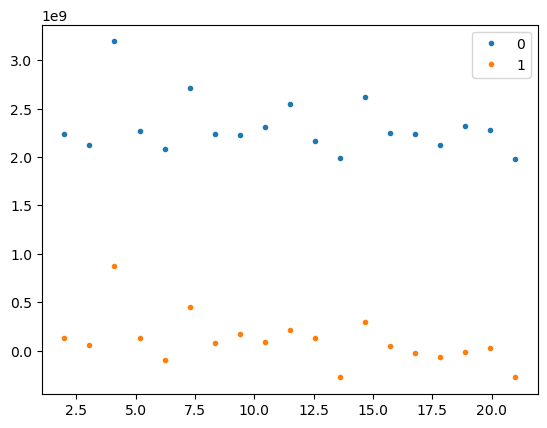

In [226]:
t = np.linspace(0,94,95)
ts = np.linspace(2,21,19)
fig, ax = plt.subplots()
ax.plot()

ax.plot(ts, arr_pos[31,1:], marker='.', ls='',label="0")
ax.plot(ts, arr_pos[32,1:], marker='.', ls='',label="1")
#ax.plot(t, arr_pos[3,1:], marker='.', ls='',label="2")
#ax.plot(t, arr_pos[4,1:], marker='.', ls='',label="3")

#ax.plot(ts, arr_pos[1,:],marker='.', ls='',label='subtracted')
#ax.plot(ts, arr_pos[4,:],marker='.', ls='',label='unsubtracted')
#ax.plot(ts, V_gs_sub[11,1:21],marker='.', ls='',label='subtracted, reconstruction')
#ax.plot(ts, V_gs_nosub[11,1:21],marker='.', ls='',label='unsubtracted, reconstruction')
#ax.plot(ts, V_001_sub[9,1:21],marker='.', ls='',label='subtracted, reconstruction')
#ax.plot(ts, V_001_nosub[9,1:21],marker='.', ls='',label='unsubtracted, reconstruction')
#ax.set_ylim(0,5.5e10)
ax.legend()

In [999]:
dst_avg = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-pos-avg-t/"
dst_sub1 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-dc-sub1/" #with tsrc
dst_sub1 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-dc-sub2/" #without tsrc
avg_data = []
sub_data1 = []
sub_data2 = []

for traj in range(1112, 1292, 10):
    sub_data1.append(q.load_lat_data(dst_sub1+f"traj-{traj}/pipi_vev_pos_avg.lat").to_numpy())
    sub_data2.append(q.load_lat_data(dst_sub2+f"traj-{traj}/pipi_vev_pos_avg.lat").to_numpy())

'''
for traj in range(1112, 1493, 10):
    avg_data.append(q.load_lat_data(dst_avg+f"traj-{traj}/pipi_vev_pos_avg.lat").to_numpy())

for traj in range(1505, 1636, 10):
    avg_data.append(q.load_lat_data(dst_avg+f"traj-{traj}/pipi_vev_pos_avg.lat").to_numpy())

for traj in range(1705, 2026, 10):
    avg_data.append(q.load_lat_data(dst_avg+f"traj-{traj}/pipi_vev_pos_avg.lat").to_numpy())

avg_data.append(q.load_lat_data(dst_avg+f"traj-{2045}/pipi_vev_pos_avg.lat").to_numpy())
avg_data.append(q.load_lat_data(dst_avg+f"traj-{2055}/pipi_vev_pos_avg.lat").to_numpy())
avg_data.append(q.load_lat_data(dst_avg+f"traj-{2065}/pipi_vev_pos_avg.lat").to_numpy())

for traj in range(2085, 2156, 10):
    avg_data.append(q.load_lat_data(dst_avg+f"traj-{traj}/pipi_vev_pos_avg.lat").to_numpy())
'''

sd_1_arr = np.array(sub_data1)

(97, 3, 25, 25, 25, 96)


In [1064]:
dst_sub3 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-dc-sub3/"
dst_sub2 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-dc-sub2/" 
sub_data3 = []
sub_data2 = []

for traj in range(1112, 1493, 10):
    #print(traj)
    #sub_data1.append(q.load_lat_data(dst_sub1+f"traj-{traj}/pipi_bubble.lat").to_numpy())
    sub_data2.append(q.load_lat_data(dst_sub2+f"traj-{traj}/pipi_bubble.lat").to_numpy())

for traj in range(1505, 1636, 10):
    #sub_data1.append(q.load_lat_data(dst_sub1+f"traj-{traj}/pipi_bubble.lat").to_numpy())
    sub_data2.append(q.load_lat_data(dst_sub2+f"traj-{traj}/pipi_bubble.lat").to_numpy())

for traj in range(1705, 1826, 10):
    #sub_data1.append(q.load_lat_data(dst_sub1+f"traj-{traj}/pipi_bubble.lat").to_numpy())
    sub_data2.append(q.load_lat_data(dst_sub2+f"traj-{traj}/pipi_bubble.lat").to_numpy())

for traj in range(1855, 2026, 10):
    #sub_data1.append(q.load_lat_data(dst_sub1+f"traj-{traj}/pipi_bubble.lat").to_numpy())
    sub_data2.append(q.load_lat_data(dst_sub2+f"traj-{traj}/pipi_bubble.lat").to_numpy())

#sub_arr1 = np.array(sub_data1)
sub_arr2 = np.array(sub_data2)
print(sub_arr2.shape)

(84, 3, 96)


In [320]:
dst_sub4 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-dc-sub5/traj-1122/pipi_vev.lat"
ld1915 = q.load_lat_data(dst_sub4)
ld1915.info()[0][2]

['< 1 >  exprs[0]',
 '< sigma(-tsep) >  exprs[1]',
 '< sigma(-tsep) - <sigma> >  exprs[2]',
 '< wf_src(0) * pipi_i0(-tsep) - <pipi> >  exprs[3]',
 '< wf_snk(0) * pipi_i0^dag(0) >  exprs[4]',
 '< wf_src(1) * pipi_i0(-tsep) - <pipi> >  exprs[5]',
 '< wf_snk(1) * pipi_i0^dag(0) >  exprs[6]',
 '< wf_src(2) * pipi_i0(-tsep) - <pipi> >  exprs[7]',
 '< wf_snk(2) * pipi_i0^dag(0) >  exprs[8]',
 '< wf_src(3) * pipi_i0(-tsep) - <pipi> >  exprs[9]',
 '< wf_snk(3) * pipi_i0^dag(0) >  exprs[10]']

In [321]:
sig_vev_1915 = ld1915.to_numpy()

In [ ]:
dst_sub4 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-dc-sub4/"

In [273]:
dst_sub4 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-dc-sub4/"
sub_data4 = []

#this is for Delta = 5
#for traj in range(1102,1203,10):
#    sub_data4.append(q.load_lat_data(dst_sub4+f"traj-{traj}/pipi_vev.lat").to_numpy())

#Delta= 1
#for traj in range(1212,1313,10):
#    sub_data4.append(q.load_lat_data(dst_sub4+f"traj-{traj}/pipi_vev.lat").to_numpy())

#Delta= 3
#for traj in range(1505,1606,10):
#    sub_data4.append(q.load_lat_data(dst_sub4+f"traj-{traj}/pipi_vev.lat").to_numpy())

#correct subtraction, Delta=5
for traj in range(1915,1996,10):
    sub_data4.append(q.load_lat_data(dst_sub4+f"traj-{traj}/pipi_vev.lat").to_numpy())

'''
sub_data3.append(q.load_lat_data(dst_sub3+f"traj-{1102}/pipi_bubble_mom.lat").to_numpy())
sub_data3.append(q.load_lat_data(dst_sub3+f"traj-{1112}/pipi_bubble_mom.lat").to_numpy())

for traj in range(1132, 1453, 10):
    #print(traj)
    sub_data3.append(q.load_lat_data(dst_sub3+f"traj-{traj}/pipi_bubble_mom.lat").to_numpy())

sub_data3.append(q.load_lat_data(dst_sub3+f"traj-{1472}/pipi_bubble_mom.lat").to_numpy())
sub_data3.append(q.load_lat_data(dst_sub3+f"traj-{1482}/pipi_bubble_mom.lat").to_numpy())
sub_data3.append(q.load_lat_data(dst_sub3+f"traj-{1492}/pipi_bubble_mom.lat").to_numpy())

for traj in range(1505, 1636, 10):
    #print(traj)
    sub_data3.append(q.load_lat_data(dst_sub3+f"traj-{traj}/pipi_bubble_mom.lat").to_numpy())

for traj in range(1705, 1876, 10):
    #print(traj)
    sub_data3.append(q.load_lat_data(dst_sub3+f"traj-{traj}/pipi_bubble_mom.lat").to_numpy())
'''

sub_arr4 = np.array(sub_data4)
print(sub_arr4.shape)

(9, 11, 96)


In [335]:
V_sigma_sub = construct_V(sub_arr4[:,2,:],Delta=0)
V_gs_sub = construct_V(sub_arr4[:,3,:],Delta=5)
V_001_sub = construct_V(sub_arr4[:,5,:],Delta=5)
V_011_sub = construct_V(sub_arr4[:,7,:],Delta=5)
V_111_sub = construct_V(sub_arr4[:,9,:],Delta=5)

V_sigma_sub_jk = jackblocks_all(V_sigma_sub,omit=[])
V_gs_sub_jk = jackblocks_all(V_gs_sub,omit=[])
V_001_sub_jk= jackblocks_all(V_001_sub,omit=[])
V_011_sub_jk= jackblocks_all(V_011_sub, omit=[])
V_111_sub_jk= jackblocks_all(V_111_sub, omit=[])

V_sigma_sub_avg, V_sigma_sub_err = jack_all(V_sigma_sub_jk.real)
V_gs_sub_avg, V_gs_sub_err = jack_all(V_gs_sub_jk.real)
V_001_sub_avg, V_001_sub_err = jack_all(V_001_sub_jk.real)
V_011_sub_avg, V_011_sub_err = jack_all(V_011_sub_jk.real)
V_111_sub_avg, V_111_sub_err = jack_all(V_111_sub_jk.real)

(9, 96)
(9, 96)
(9, 96)
(9, 96)
(9, 96)


In [336]:
V_sigma_re = construct_V(sub_arr4[:,1,:],Delta=0)
V_gs_re = construct_V(sub_arr4[:,4,:],Delta=5)
V_001_re = construct_V(sub_arr4[:,6,:],Delta=5)
V_011_re = construct_V(sub_arr4[:,8,:],Delta=5)
V_111_re = construct_V(sub_arr4[:,10,:],Delta=5)

V_sigma_re_jk= jackblocks_all(V_sigma_re, omit=[])
V_gs_re_jk = jackblocks_all(V_gs_re,omit=[])
V_001_re_jk = jackblocks_all(V_001_re, omit=[])
V_011_re_jk = jackblocks_all(V_011_re, omit=[])
V_111_re_jk = jackblocks_all(V_111_re, omit=[])

V_sigma_avg, V_sigma_err = jack_all(V_sigma_re_jk.real)
V_gs_avg, V_gs_err = jack_all(V_gs_re_jk.real)
V_001_avg, V_001_err = jack_all(V_001_re_jk.real)
V_011_avg, V_011_err = jack_all(V_011_re_jk.real)
V_111_avg, V_111_err = jack_all(V_111_re_jk.real)

(9, 96)
(9, 96)
(9, 96)
(9, 96)
(9, 96)


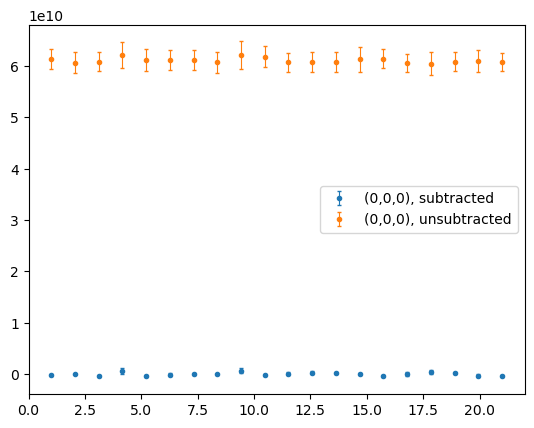

In [338]:
ts = np.linspace(1,21,20)
nt = np.linspace(1,96,96)
fig, ax = plt.subplots()

#ax.errorbar(ts, V_sigma_sub_avg[1:21], yerr=V_sigma_sub_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(0,0,0), subtracted')
#ax.errorbar(ts, V_sigma_avg[1:21], yerr=V_sigma_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(0,0,0), unsubtracted')

ax.errorbar(ts, V_gs_sub_avg[1:21], yerr=V_gs_sub_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(0,0,0), subtracted')
ax.errorbar(ts, V_gs_avg[1:21], yerr=V_gs_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(0,0,0), unsubtracted')

#ax.errorbar(ts, V_001_sub_avg[1:21], yerr=V_001_sub_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(0,0,1), subtracted')
#ax.errorbar(ts, V_001_avg[1:21], yerr=V_001_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(0,0,1), unsubtracted')

#ax.errorbar(ts, V_011_sub_avg[1:21], yerr=V_011_sub_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(0,1,1), subtracted')
#ax.errorbar(ts, V_011_avg[1:21], yerr=V_011_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(0,1,1), unsubtracted')

#ax.errorbar(ts, V_111_sub_avg[1:21], yerr=V_111_sub_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(1,1,1), subtracted')
#ax.errorbar(ts, V_111_avg[1:21], yerr=V_111_err[1:21], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='(1,1,1), unsubtracted')

# vac indices are 6, 30, 54, and 78
#ax.errorbar(ts, pipi_p_type_avg[6,:], yerr=pipi_p_type_err[6,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"$\langle O_{\pi\pi, 1} O_{\pi\pi, 1}^{\dagger} \rangle$, V")
#ax.set_xlim(0,21)
ax.legend();

In [1246]:
#pi1_jks = jackblocks_all(sub_arr1[:,1:,:],omit=[])
pi2_jks = jackblocks_all(sub_arr2[:,1:,:],omit=[])
pi3_jks = jackblocks_all(sub_arr3[:,1:,:],omit=[])

#pi1_avg, pi1_err = jack_all(pi1_jks.real)
pi2_avg, pi2_err = jack_all(pi2_jks.real)
pi3_avg, pi3_err = jack_all(pi3_jks.real)
print(pi3_avg.shape)

(8, 96)


In [293]:
bubble_gs_sub = sub_arr4[:,1,:]
bubble_gs = sub_arr4[:,2,:]

bubble_gs_sub_jk = jackblocks_all(bubble_gs_sub,omit=[])
bubble_gs = jackblocks_all(bubble_gs,omit=[])

b_sub_avg, b_sub_err = jack_all(bubble_gs_sub_jk.real)
b_avg, b_err = jack_all(bubble_gs.real)
print(b_avg.shape)

(96,)


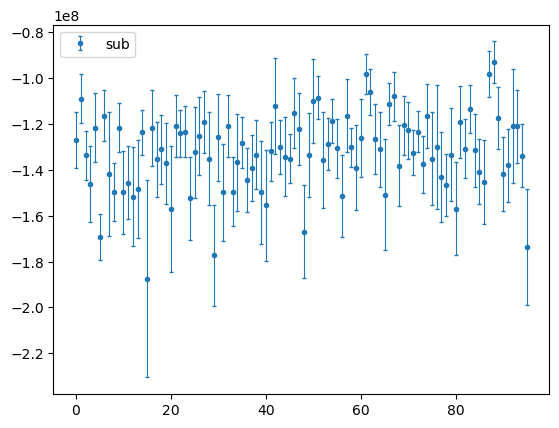

In [294]:
nt = np.linspace(0,95,96)
fig, ax = plt.subplots()
ax.errorbar(nt, b_sub_avg, yerr = b_sub_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="sub")
#ax.errorbar(nt, b_avg, yerr = b_err, marker='.', ls='', elinewidth=0.8, capsize=1.5, label="no sub")
ax.legend()
#plt.savefig("single_vev_compare.pdf",bbox_inches='tight')
#ax.set_ylim(-50000,5000)

In [296]:
#function that constructs the vacuum term of the pipi two point function from the raw subtracted bubble correlator data.
#the V term needs to be constructed config by config. 
def construct_V(bubble_raw,Delta):
    ncf = bubble_raw.shape[0]
    nt = bubble_raw.shape[-1]
    tsep_max = 24
    vac = np.zeros((ncf, tsep_max),dtype=np.complex128)

    for cf in range(ncf):
        for tsep in range(tsep_max):
            for t_src in range(nt):
                t1 = t_src
                t2 = (tsep + t_src + Delta) % nt

                vac[cf,tsep] += (bubble_raw[cf,t1] * bubble_raw[cf,t2])

    print(vac.shape)
    return vac

In [1084]:
Vsub = construct_V(sub_arr2[:,1,:],Delta=5)
Vnosub = construct_V(sub_arr2[:,2,:],Delta=5)

(84, 24)
(84, 24)


In [1085]:
Vsub_jk = jackblocks_all(Vsub,omit=[])
Vsub_avg, Vsub_err = jack_all(Vsub_jk.real)

Vnosub_jk = jackblocks_all(Vnosub,omit=[])
Vnosub_avg, Vnosub_err = jack_all(Vnosub_jk.real)

print(Vsub_avg.shape)

(24,)


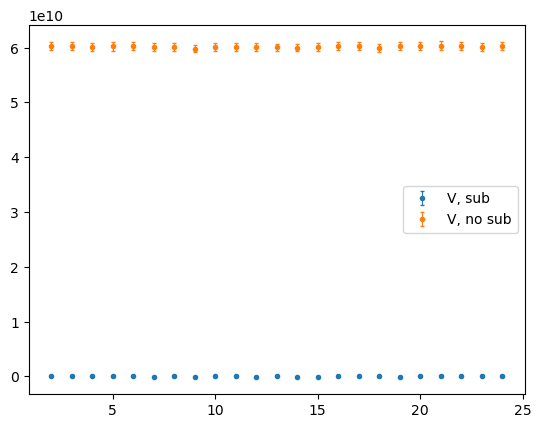

In [1160]:
ts = np.linspace(2,24,23)
fig, ax = plt.subplots()
ax.errorbar(ts, Vsub_avg[1:], yerr=Vsub_err[1:], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='V, sub')
ax.errorbar(ts, Vnosub_avg[1:], yerr=Vnosub_err[1:], marker='.', ls='', elinewidth=0.8, capsize=1.5,label='V, no sub')
#ax.set_ylim(-5e9, 5e9)
ax.legend()
plt.savefig("sub_nosub_compare.pdf",bbox_inches='tight')

In [237]:
C_gs = pipi_arr_p[:,7,:]
D_gs = pipi_arr_p[:,8,:]
R_gs = pipi_arr_p[:,9,:]
V_gs = Vsub_arr[:]

C_001 = pipi_arr_p[:70,31,:]
D_001 = pipi_arr_p[:70,32,:]
R_001 = pipi_arr_p[:70,33,:]

C_011 = pipi_arr_p[:70,55,:]
D_011 = pipi_arr_p[:70,56,:]
R_011 = pipi_arr_p[:70,57,:]

C_111 = pipi_arr_p[:70,79,:]
D_111 = pipi_arr_p[:70,80,:]
R_111 = pipi_arr_p[:70,81,:]

In [238]:
#do the type sum on a configuration by configuration basis
def type_sum(V_data, C_data, D_data, R_data):
    #each of these input arays has shape (ncf, tsep_max)
    ncf = C_data.shape[0]
    tsep_max = C_data.shape[1]
    assert V_data.shape[0] == C_data.shape[0] 

    corr_sum = np.zeros_like(C_data)
    for cf in range(ncf):
        corr_sum[cf, :] = C_data[cf,:] + D_data[cf,:] + R_data[cf,:] + V_data[cf,1:21]

    return corr_sum

In [239]:
corr_total_gs = type_sum(V_gs_sub, C_gs, D_gs, R_gs)
corr_total_001 = type_sum(V_001_sub, C_001, D_001, R_001)
corr_total_011 = type_sum(V_011_sub, C_011, D_011, R_011)
corr_total_111 = type_sum(V_111_sub, C_111, D_111, R_111)
#corr_total_gs_nosub = type_sum(V_gs_re, C_gs, D_gs, R_gs)

corr_total_gs_jk = jackblocks_all(corr_total_gs, omit=[])
corr_total_001_jk = jackblocks_all(corr_total_001, omit=[])
corr_total_011_jk = jackblocks_all(corr_total_011, omit=[])
corr_total_111_jk = jackblocks_all(corr_total_111, omit=[])
#corr_total_ns_jk = jackblocks_all(corr_total_nosub,omit=[])

corr_sub_gs_avg, corr_sub_gs_err = jack_all(corr_total_gs_jk.real)
corr_sub_001_avg, corr_sub_001_err = jack_all(corr_total_001_jk.real)
corr_sub_011_avg, corr_sub_011_err = jack_all(corr_total_011_jk.real)
corr_sub_111_avg, corr_sub_111_err = jack_all(corr_total_111_jk.real)
#corr_nosub_avg, corr_nosub_err = jack_all(corr_total_ns_jk.real)

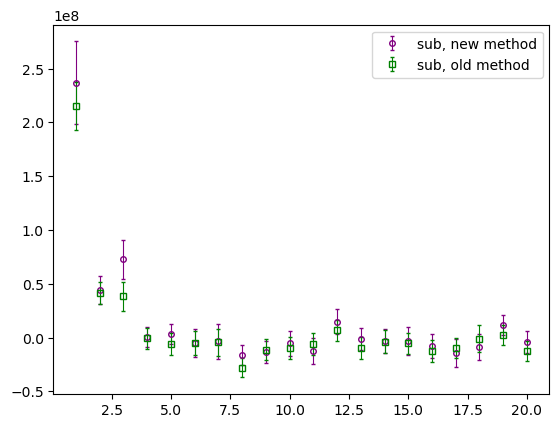

In [349]:
ts = np.linspace(1,20,20)
fig, ax = plt.subplots()

#ax.errorbar(ts, corr_sub_gs_avg, yerr=corr_sub_gs_err, marker='o', markersize=4, markerfacecolor= 'none', markeredgecolor= 'purple', ls='', elinewidth=0.8, capsize=1.5, color='purple', label='sub, new method')
#ax.errorbar(ts, C_sub_avg[0,0], yerr=C_sub_err[0,0], marker='s', markersize=4, markerfacecolor= 'none', markeredgecolor= 'green', ls='', elinewidth=0.8, capsize=1.5, color='green', label=r"sub, old method")

#ax.errorbar(ts, corr_sub_001_avg, yerr=corr_sub_001_err, marker='o', markersize=4, markerfacecolor= 'none', markeredgecolor= 'purple', ls='', elinewidth=0.8, capsize=1.5, color='purple', label='sub, new method')
#ax.errorbar(ts, C_sub_avg[2,2], yerr=C_sub_err[2,2], marker='s', markersize=4, markerfacecolor= 'none', markeredgecolor= 'green', ls='', elinewidth=0.8, capsize=1.5, color='green', label=r"sub, old method")

#ax.errorbar(ts, corr_sub_011_avg, yerr=corr_sub_011_err, marker='o', markersize=4, markerfacecolor= 'none', markeredgecolor= 'purple', ls='', elinewidth=0.8, capsize=1.5, color='purple', label='sub, new method')
#ax.errorbar(ts, C_sub_avg[3,3], yerr=C_sub_err[3,3], marker='s', markersize=4, markerfacecolor= 'none', markeredgecolor= 'green', ls='', elinewidth=0.8, capsize=1.5, color='green', label=r"sub, old method")

ax.errorbar(ts, corr_sub_111_avg, yerr=corr_sub_111_err, marker='o', markersize=4, markerfacecolor= 'none', markeredgecolor= 'purple', ls='', elinewidth=0.8, capsize=1.5, color='purple', label='sub, new method')
ax.errorbar(ts, C_sub_avg[4,4], yerr=C_sub_err[4,4], marker='s', markersize=4, markerfacecolor= 'none', markeredgecolor= 'green', ls='', elinewidth=0.8, capsize=1.5, color='green', label=r"sub, old method")

#ax.errorbar(ts, corr_nosub_avg, yerr=corr_nosub_err, marker='.', ls='', elinewidth=0.8, capsize=1.5,label='no sub, new method')
#ax.errorbar(ts, C_pipi_p_avg[0,0,:], yerr=C_pipi_p_err[0,0,:], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"no sub, old method")

#ax.set_ylim(1e9,1e10)
#ax.set_xlim(10,21)
#ax.set_yscale("log")
ax.legend()
#plt.savefig("sub_compare_zoom.pdf",bbox_inches='tight')

In [1332]:
sub_corr_jk.shape

(84, 20)

In [272]:
eff_mass_new = eff_mass_2d_ln_half(corr_total_gs_jk.real)
eff_mass_old = eff_mass_2d_ln_half(C_sub_jk[:,0,0,:].real)

em_new_avg, em_new_err = jack_all(eff_mass_new)
em_old_avg, em_old_err = jack_all(eff_mass_old)
print(em_new_avg.shape)

(18,)


In [255]:
ts_em

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18.])

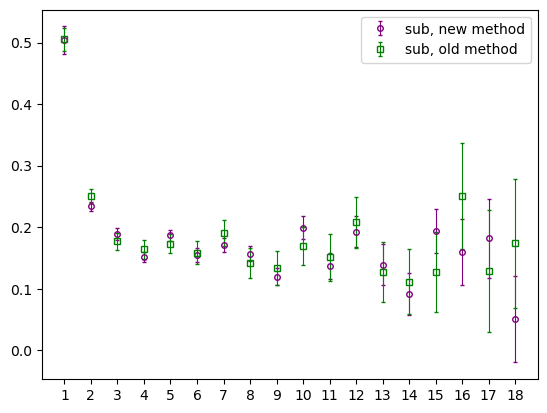

In [273]:
ts_em = np.linspace(1,18,18)
fig, ax = plt.subplots()
ax.errorbar(ts_em, em_new_avg, yerr=em_new_err, marker='o', markersize=4, markerfacecolor= 'none', markeredgecolor= 'purple', ls='', elinewidth=0.8, capsize=1.5, color='purple', label='sub, new method')
ax.errorbar(ts_em, em_old_avg, yerr=em_old_err, marker='s', markersize=4, markerfacecolor= 'none', markeredgecolor= 'green', ls='', elinewidth=0.8, capsize=1.5, color='green', label=r"sub, old method")
ax.set_xticks(ts_em)
ax.legend()

In [323]:
Enew, Enew_err, Enew_jk, chi2_dof_new = meson_energy_new(corr_total_gs_jk.real,4,14)
E, E_err, E_jk, chi2_dof = meson_energy_new(C_sub_jk[:,0,0,:].real,4,14)

In [324]:
print(f"correlator exponential fit, E: {E} +/- {E_err}")
print(f"correlator exponential fit, E_new: {Enew} +/- {Enew_err}")

correlator exponential fit, E: 0.16005656516736733 +/- 0.002101275102605897
correlator exponential fit, E_new: 0.1586353516841886 +/- 0.001588896041258797


In [329]:
Enew_em, Enew_em_err, Enew_em_jk, chi2_dof_new = eff_mass_energy(eff_mass_new, 4,14)
E_em, E_em_err, E_em_jk, chi2_dof = eff_mass_energy(eff_mass_old,4,14)

In [330]:
print(f"eff mass constant fit, E: {E_em} +/- {E_em_err}")
print(f"eff mass constant fit, E_new: {Enew_em} +/- {Enew_em_err}")

eff mass constant fit, E: 0.162944516857919 +/- 0.005069261927407315
eff mass constant fit, E_new: 0.16424805028165074 +/- 0.003203142282059493


In [1254]:
counter = np.sum(avg_arr[:,0,:,:,:,:],axis=-1)
pi = np.sum(avg_arr[:,1,:,:,:,:],axis=-1)

counter_jk = jackblocks_all(counter,omit=[])
pi_jk = jackblocks_all(pi,omit=[])

pi_norm_jk = np.zeros_like(pi_jk)
pi_norm_jk = np.divide(pi_jk, counter_jk,where=(counter_jk>0))
print(pi_norm_jk.shape)

pi_avg, pi_err = jack_all(pi_norm_jk)

print(pi_avg.shape)
np.save("pipi_avg_data",pi_avg)

(97, 25, 25, 25)
(25, 25, 25)


In [631]:
#This does not work. 
#first do the average with the counter array per configuration
ncf = len(avg_data)
NS_mod = avg_arr.shape[-1]
pipi_avg_arr = np.zeros((ncf, NS_mod, NS_mod, NS_mod),np.complex128)
for cf in range(ncf):
    counter = avg_arr[cf,0,:,:,:]
    mask = (counter != 0) #we only want to divide by entries that are non-zero
    pipi_avg_arr[cf, mask] = avg_arr[cf,1,mask]/counter[mask]

print(pipi_avg_arr.shape)

(49, 25, 25, 25)


In [632]:
pipi_avg_jk = jackblocks_pos(pipi_avg_arr, omit=[])
print(pipi_avg_jk.shape)

(49, 25, 25, 25)


In [633]:
pipi_avg_avg, pipi_avg_err = jack(pipi_avg_jk)
pipi_avg_whole = np.array([pipi_avg_avg, pipi_avg_err])
print(pipi_avg_avg.shape)
np.save("pipi_avg_data", pipi_avg_avg)

(25, 25, 25)


In [941]:
dst_bubble = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-dc-sub/"
dst_pi = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-pos-avg-t/"
dst_pi_2 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-pos-avg/"
bubble_data = []
avg_data_pipi = []
avg_data_pipi2 = []


for traj in range(1112, 1213, 10):
    avg_data_pipi.append(q.load_lat_data(dst_pi+f"traj-{traj}/pipi_vev_pos_avg.lat").to_numpy())
    avg_data_pipi2.append(q.load_lat_data(dst_pi_2+f"traj-{traj}/pipi_vev_pos_avg.lat").to_numpy())

for traj in range(1142, 1493, 10):
    bubble_data.append(q.load_lat_data(dst_bubble+f"traj-{traj}/pipi_vev.lat").to_numpy())

for traj in range(1505, 1596, 10):
    bubble_data.append(q.load_lat_data(dst_bubble+f"traj-{traj}/pipi_vev.lat").to_numpy())

bubble_arr = np.array(bubble_data)
pi_arr = np.array(avg_data_pipi)
pi_arr2 = np.array(avg_data_pipi2)
print(bubble_arr.shape)

(46, 3, 96)


In [784]:
ncf = len(bubble_data)
Delta = 5
nt = 96
tsep_max = 20
vac = np.zeros((ncf, tsep_max),dtype=np.complex128)

for cf in range(ncf):
    for tsep in range(tsep_max):
        for t_src in range(nt):
            t1 = t_src
            t2 = (tsep + t_src + Delta) % nt

            vac[cf, tsep] += (bubble_arr[cf,1,t1] * bubble_arr[cf,1,t2])

print(vac.shape)

(46, 20)


In [785]:
vac_jk = jackblocks(vac,omit=[])

In [786]:
vac_avg, vac_err = jack(vac_jk.real)
print(vac_avg.shape)

(20,)


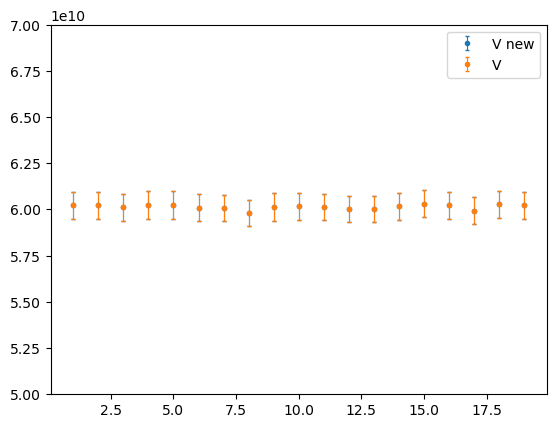

In [1157]:
ts = np.linspace(1,19,19)
fig, ax = plt.subplots()
ax.errorbar(ts, Vnosub_avg[1:20], yerr=Vnosub_err[1:20], marker='.', ls='', elinewidth=0.8, capsize=1.5, label='V new')
ax.errorbar(ts, pipi_p_type_avg[6,0:19], yerr=pipi_p_type_err[6,0:19], marker='.', ls='', elinewidth=0.8, capsize=1.5, label=r"V")
ax.set_ylim(5e10, 7e10)
ax.legend()
plt.savefig("V_compare.pdf",bbox_inches='tight')

In [871]:
vev_gs.shape

(11, 96)

In [702]:
pipi_p_type_avg[6,:20]

array([5.96252141e+10, 5.97201590e+10, 5.92303000e+10, 5.99779782e+10,
       5.95063682e+10, 5.94325394e+10, 5.94966581e+10, 5.89719271e+10,
       5.96346184e+10, 5.94631084e+10, 5.90799511e+10, 5.98582905e+10,
       5.91621437e+10, 5.95889331e+10, 5.96948754e+10, 5.92259550e+10,
       5.97789078e+10, 5.95371942e+10, 5.98643917e+10, 6.01137987e+10])

In [762]:
bubble_arr[0,2,:24] #- bubble_arr[0,1,:24]

array([-32633.35381071 -40.26898691j, -33648.38752657-110.23907855j,
       -22816.76654025 +13.74337748j, -11185.52477471 -15.95899716j,
       -43544.1475614  -37.36895194j, -26542.92126598 +36.85891487j,
       -15908.51845296+102.68083998j, -20850.93966894 +45.73993167j,
        -7140.14896846  -0.98550191j, -22069.42319581  +2.81707008j,
       -21325.11622818 -16.76070244j, -34352.63922464+154.13017067j,
       -20178.4486499  +76.0187826j ,  -9560.71263611  +8.50718663j,
       -11336.21423316 -35.74577202j, -24574.05499841  +2.00012681j,
       -27005.93636582 +62.84408056j, -24767.84391637 -49.28333618j,
       -19577.53056476  -3.80458105j, -12246.32562907 +58.20762265j,
       -30322.88556893+131.11488255j, -28576.84904606-604.40587567j,
       -22475.60480719 -62.41233027j, -31606.42978109  +1.90459901j])

In [894]:
counter = pi_arr[:,0,:,:,:,:]
pi = pi_arr[:,1,:,:,:,:]

In [957]:
pi[1,11,12,10,25]/counter[1,11,12,10,25]

/tmp/ipykernel_2714810/73960515.py:1: RuntimeWarning: invalid value encountered in scalar divide
  pi[1,11,12,10,25]/counter[1,11,12,10,25]


np.complex128(nan+nanj)

In [909]:
pi_t = np.sum(np.sum(np.sum(pi,axis=1),axis=1),axis=1)
counter_t = np.sum(np.sum(np.sum(counter,axis=1),axis=1),axis=1)

pi_norm = pi_t/counter_t
print(pi_norm.shape)

(11, 96)


In [827]:
mask = (counter != 0)

pi_norm = np.zeros_like(pi)
pi_norm[mask] = pi[mask]/counter[mask]

In [910]:
pi_norm_jk = jackblocks(pi_norm, omit=[])

In [911]:
pi_norm_avg, pi_norm_err = jack(pi_norm_jk)

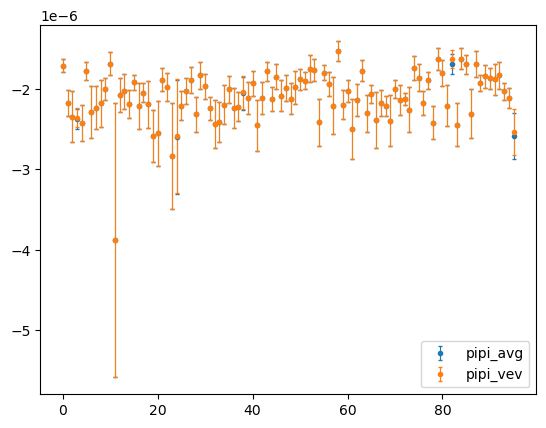

In [913]:
t = np.linspace(0,95,96)
fig,ax = plt.subplots()
ax.errorbar(t,pi_norm_avg, yerr=pi_norm_err,marker='.', ls='', elinewidth=0.8, capsize=1.5, label="pipi_avg")
ax.errorbar(t,vev_gs_avg, yerr=vev_gs_err,marker='.', ls='', elinewidth=0.8, capsize=1.5, label="pipi_vev")
ax.legend()

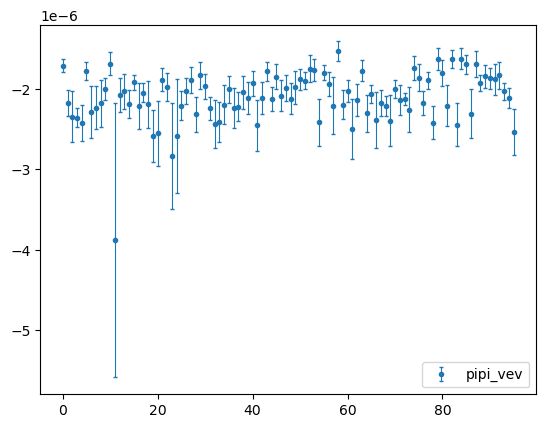

In [874]:
t = np.linspace(0,95,96)
fig,ax = plt.subplots()
#ax.errorbar(t,pi_t_avg, yerr=pi_t_err,marker='.', ls='', elinewidth=0.8, capsize=1.5, label="pipi_avg")
ax.errorbar(t,vev_gs_avg, yerr=vev_gs_err,marker='.', ls='', elinewidth=0.8, capsize=1.5, label="pipi_vev")
ax.legend()

In [872]:
vev_gs_jks = jackblocks(vev_gs/vev_count, omit=[])

In [873]:
vev_gs_avg, vev_gs_err = jack(vev_gs_jks)

In [900]:
pi_norm_avg[:24]

array([-1.09222610e-10+1.24081998e-13j, -1.39030354e-10+8.56876679e-14j,
       -1.49897557e-10-3.00049276e-13j, -1.51882019e-10+1.74137978e-13j,
       -1.55139978e-10+6.55006437e-14j, -1.13731049e-10-1.69189312e-14j,
       -1.46231065e-10-1.13715483e-12j, -1.42911267e-10+8.04526705e-13j,
       -1.39460594e-10+2.01095850e-14j, -1.27968625e-10+7.34299870e-14j,
       -1.07741405e-10+4.60579350e-13j, -2.48367816e-10-3.67161077e-13j,
       -1.32783646e-10-3.38868342e-13j, -1.29682548e-10-6.43848964e-13j,
       -1.39836363e-10-9.09098493e-14j, -1.22658648e-10+1.86107270e-15j,
       -1.41675833e-10+2.85603030e-13j, -1.30799962e-10-4.75682922e-13j,
       -1.40235128e-10+4.64511668e-13j, -1.65144464e-10-1.24053943e-13j,
       -1.63241458e-10+3.85950081e-13j, -1.20624904e-10-3.77106660e-13j,
       -1.26551896e-10+3.15451549e-14j, -1.81161264e-10+2.56078896e-13j])

In [901]:
vev_gs_avg[:24]

array([-1.70660328e-06+1.93878122e-09j, -2.17234928e-06+1.33886981e-09j,
       -2.34214933e-06-4.68826994e-09j, -2.35459587e-06+2.70850223e-09j,
       -2.42406216e-06+1.02344756e-09j, -1.77704765e-06-2.64358300e-10j,
       -2.28486039e-06-1.77680442e-08j, -2.23298855e-06+1.25707298e-08j,
       -2.17907179e-06+3.14212265e-10j, -1.99950977e-06+1.14734355e-09j,
       -1.68345945e-06+7.19655234e-09j, -3.88074713e-06-5.73689183e-09j,
       -2.07474447e-06-5.29481784e-09j, -2.02628981e-06-1.00601401e-08j,
       -2.18494317e-06-1.42046640e-09j, -1.91654137e-06+2.90792610e-11j,
       -2.21368489e-06+4.46254734e-09j, -2.04374941e-06-7.43254566e-09j,
       -2.19117388e-06+7.25799482e-09j, -2.58038225e-06-1.93834286e-09j,
       -2.55064778e-06+6.03047002e-09j, -1.88476412e-06-5.89229157e-09j,
       -1.97737337e-06+4.92893046e-10j, -2.83064474e-06+4.00123274e-09j])

In [892]:
vev_count[0,:24]

array([1.05076777e+10+0.j, 1.53180979e+10+0.j, 1.03195607e+10+0.j,
       1.25769646e+10+0.j, 5.07915878e+09+0.j, 1.66886646e+10+0.j,
       7.65904896e+09+0.j, 9.02961562e+09+0.j, 7.73967053e+09+0.j,
       7.73967053e+09+0.j, 1.66886646e+10+0.j, 1.00776960e+10+0.j,
       1.29800724e+10+0.j, 9.02961562e+09+0.j, 1.11795241e+10+0.j,
       1.42162698e+10+0.j, 1.61243136e+10+0.j, 1.11257764e+10+0.j,
       9.02961562e+09+0.j, 7.33656269e+09+0.j, 1.35981711e+10+0.j,
       2.06391214e+10+0.j, 1.11257764e+10+0.j, 8.16965222e+09+0.j])

In [891]:
counter_t = np.sum(np.sum(np.sum(counter,axis=1),axis=1),axis=1)

In [905]:
vev_count[3,:24]/counter_t[3,:24]

array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [888]:
mask = ()

162.76041666666666

In [975]:
pi_arr_space_0 = np.sum(pi_arr,axis=-1)
counter = pi_arr_space_0[:,0,:,:,:]
pi = pi_arr_space_0[:,2,:,:,:]

counter_jks = jackblocks_pos(counter,omit=[])
pi_jks = jackblocks_pos(pi, omit=[])

In [963]:
pi_arr_space_0 = np.sum(pi_arr,axis=-1)
counter = pi_arr_space_0[:,0,:,:,:]
pi = pi_arr_space_0[:,2,:,:,:]

mask = (counter != 0)
pi_norm = np.zeros_like(pi)
pi_norm[mask] = pi[mask]/counter[mask]

pi_norm_jk = jackblocks_pos(pi_norm,omit=[])

pi_norm_avg, pi_norm_err = jack_pos(pi_norm_jk)

In [973]:
pi[1,12,11,6]/counter[1,12,11,6]

np.complex128(-7.241792923302746e-07-3.073303572682907e-08j)

In [965]:
pi_norm_jk[0,10,11,12]

np.complex128(-2.0516299916935407e-07+9.811273401572715e-10j)

In [964]:
pi_norm_avg[10,11,12]

np.complex128(-1.8651181742668546e-07+8.919339455975193e-10j)

In [956]:
(pi_arr2[1,1,11,10,12]/pi_arr2[1,0,11,10,12])

np.complex128(-1.3376574043069063e-06+2.516194747021553e-10j)

In [978]:
pi_jks[1,12,11,20]

np.complex128(-130.4093991309973+4.846886880843433j)

In [979]:
counter_jks[1,12,11,20]

np.complex128(61809868.80000003+0j)

In [980]:
counter[1,12,11,20]

np.complex128(483729408.00000006+0j)

In [981]:
pi_jks[1,12,11,20]/counter_jks[1,12,11,20]

np.complex128(-2.1098475318394014e-06+7.841606809628806e-08j)

In [989]:
counter[1,12,11,20]/counter_jks[1,12,11,20]

np.complex128(7.826086956521736+0j)

In [ ]:
np.sum(np.sum(np.sum(pi_arr2[0,1,:,:,:] - pi_arr_space[])))

In [ ]:
pi_jk = jackblocks()

In [ ]:
'''
Notes on debugging the pi_avg issue. 

1. The product of unsubtracted bubbles is EXACTLY the same as the vacuum term from the pipi two point function. This is a good thing. 

2. The average term, summed over its spatial axes, which represent the relative spatial separation between source and sink, gives the EXACT(very close) result as the pipi vev as a function of t_src. This is also good. 

This means both items individually are being calculated correctly. 

3. The unsubtracted bubble for a single source-sink pair is on the same scale as the counter normalized pipi vev. This is also good. 

The question remains, why does the subtraction barely affect the bubble terms in the code. 

4. I have two sets of average data, one is saved in terms of the relative spatial separation, the other in terms of the relative spatial separation, and the source timeslice. The data averaged over equivalent relative spatial separations 
   on each timeslice is on the same scale as the bubble term for a single source-sink pair. 

   I am not sure how good of a test this is, because the thing that we are supposed to be subtracting is an ensemble average of the pipi_avg data. Since the pipi_avg data is incredibly sparse (this is something to look into), one configuration may be populated while 
   the next one isn't at a given relative coordinate configuration, meaning that when we do the ensemble average, we are artificially decreasing the value of the subtraction term. 

I could normalize by the average counter array, <pipi>/<1>, this is what I did when looking at the improvement of the single pion, and it found the same physics. This will account for this artificial decrease of the subtraction term when we average over sparse matrices
because the exact same artificial decrease happens in the <1> quantity. This can be seen very briefly above, comparing the jackblocked counter array vs the raw counter array, and the ratio <pipi/C> vs <pipi>/<C>. Practically speaking, the subtraction smaller than it 
should be by a factor of 7 on average, and the ratio C/<C> for the single instance I tested is about 8. This is promising for fixing the magnitude issue. 


'''